# Lecture 9: ANOVA, Interactions, and Model Structure

## Contents
- [9.1 Recap and regression notation](#section-91)
- [9.2 Categorical predictors](#section-92)
- [9.3 Interactions](#section-93)
- [9.4 Continuous versus categorized predictors](#section-94)
- [9.5 Whole-model effect sizes](#section-95)
- [9.6 Interaction interpretation](#section-96)
- [9.7 Modeling choices with messy data](#section-97)
- [9.8 Frequentist translation](#section-98)
- [9.9 Assumptions and limitations](#section-99)
- [9.10 For next time](#section-910)


## Setup

### Data access policy

This notebook follows the Lecture 7 and Lecture 8 data policy. It first looks for
required CSV files in local course-data folders, especially `public_content/Data`
when run from the repository and `../public_content/Data` when run from the
`Notebooks` folder. If a file is missing, the notebook downloads a copy into a
local `data` folder.

Palmer penguins are loaded with `palmerpenguins.load_penguins()` so students see
the same dataset source they used earlier in the course.


In [189]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])


for pip_name, import_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("pymc", "pymc"),
    ("arviz", "arviz"),
    ("preliz", "preliz"),
    ("bambi", "bambi"),
    ("palmerpenguins", "palmerpenguins"),
]:
    ensure_package(pip_name, import_name)


### Required data files


In [190]:
REQUIRED_DATA_FILES = {
    "ToothGrowth.csv": "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/ToothGrowth.csv",
    "births14.csv": "https://csvbase.com/rmirror/births14",
}


### Resolve required data files


In [191]:
from pathlib import Path
import urllib.request

SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("public_content") / "Data",
    Path("..") / "data",
    Path("..") / "Data",
    Path("..") / "public_content" / "Data",
]

DATA_FILE_PATHS = {}
for filename, url in REQUIRED_DATA_FILES.items():
    local_path = next((folder / filename for folder in SEARCH_DIRS if (folder / filename).exists()), None)
    if local_path is None:
        data_dir = Path("data")
        data_dir.mkdir(exist_ok=True)
        local_path = data_dir / filename
        urllib.request.urlretrieve(url, local_path)
    DATA_FILE_PATHS[filename] = local_path

DATA_FILE_PATHS


{'ToothGrowth.csv': WindowsPath('../public_content/Data/ToothGrowth.csv'),
 'births14.csv': WindowsPath('../public_content/Data/births14.csv')}

### Imports and plotting defaults

The palette continues the Lecture 7 and 8 visual language: charcoal for observed
data, blue for mean structures, green for posterior predictive quantities, and
orange or purple for contrasts and reference ideas.


In [192]:
import os
import warnings

TMP_NUMBA_DIR = "/tmp/numba-codex"
TMP_PYTENSOR_DIR = "/tmp/pytensor-codex"
os.makedirs(TMP_NUMBA_DIR, exist_ok=True)
os.makedirs(TMP_PYTENSOR_DIR, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", TMP_NUMBA_DIR)
os.environ.setdefault("PYTENSOR_BASE_COMPILEDIR", TMP_PYTENSOR_DIR)
os.environ.setdefault("PYTENSOR_FLAGS", f"base_compiledir={TMP_PYTENSOR_DIR}")

from IPython.display import Markdown, display
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import xarray as xr
from palmerpenguins import load_penguins

print(f"arviz: {az.__version__}")
print(f"bambi: {bmb.__version__}")
print(f"pymc: {pm.__version__}")
print(f"preliz: {pz.__version__}")
print(f"xarray: {xr.__version__}")

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 36714361
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
az.style.use("arviz-whitegrid")

COLORS = {
    "observed": "#30343B",
    "mean": "#0072B2",
    "predictive": "#009E73",
    "contrast": "#D55E00",
    "interaction": "#6A3D9A",
    "reference": "#A65E00",
    "female": "#CC79A7",
    "male": "#009E73",
    "light": "#D9ECF7",
    "smoker": "#D55E00",
    "nonsmoker": "#0072B2",
    "residual": "#7F7F7F",
}

LABELS = {
    "body_mass_g": "Body mass (g)",
    "flipper_length_mm": "Flipper length (mm)",
    "bill_length_mm": "Bill length (mm)",
    "len": "Tooth length",
    "dose": "Dose",
    "birth_weight": "Birth weight (g)",
    "gestation_weeks": "Gestation (weeks)",
}


arviz: 0.23.4
bambi: 0.17.2
pymc: 5.28.1
preliz: 0.24.0
xarray: 2025.3.1


### Helper functions


In [193]:
def style_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)
    return ax


def check_diagnostics(idata, var_names):
    summary = az.summary(idata, var_names=var_names)
    n_divergences = int(idata.sample_stats["diverging"].sum())
    display(Markdown(f"**Divergences:** {n_divergences}"))
    return summary[["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]]


def posterior_array(idata, var_name):
    return az.extract(idata)[var_name].to_numpy()


def hdi_interval(samples, prob=0.94):
    hdi = az.hdi(np.asarray(samples), hdi_prob=prob)
    return hdi[0], hdi[1]


### Load and derive analysis data frames


In [194]:
penguins = load_penguins()
penguins = penguins.dropna(
    subset=["body_mass_g", "flipper_length_mm", "bill_length_mm", "species", "sex"]
).copy()
penguins["species"] = pd.Categorical(
    penguins["species"],
    categories=["Adelie", "Chinstrap", "Gentoo"],
    ordered=True,
)
penguins["sex"] = pd.Categorical(
    penguins["sex"].str.lower(),
    categories=["female", "male"],
    ordered=True,
)
penguins = penguins.dropna(subset=["species", "sex"]).reset_index(drop=True)

toothgrowth = pd.read_csv(DATA_FILE_PATHS["ToothGrowth.csv"])
toothgrowth = toothgrowth.drop(columns=[col for col in ["rownames"] if col in toothgrowth.columns])
toothgrowth["supp"] = pd.Categorical(toothgrowth["supp"], categories=["VC", "OJ"], ordered=True)
toothgrowth["dose"] = toothgrowth["dose"].astype(float)

births14_raw = pd.read_csv(DATA_FILE_PATHS["births14.csv"])
births14 = births14_raw.copy()
births14["birth_weight"] = births14["weight"] * 453.59237
births14["gestation_weeks"] = births14["weeks"]
births14["smoking"] = pd.Categorical(
    births14["habit"],
    categories=["nonsmoker", "smoker"],
    ordered=True,
)
births14["prematurity"] = pd.Categorical(
    births14["premie"],
    categories=["full term", "premie"],
    ordered=True,
)
gestation_category_order = ["very preterm", "preterm", "early/full term"]
births14["gestation_category"] = pd.cut(
    births14["gestation_weeks"],
    bins=[-np.inf, 32, 37, np.inf],
    labels=gestation_category_order,
    right=False,
    ordered=True,
)
births14 = births14.dropna(
    subset=["birth_weight", "gestation_weeks", "smoking", "gestation_category"]
).reset_index(drop=True)

print(f"Penguins: {penguins.shape}")
print(f"ToothGrowth: {toothgrowth.shape}")
print(f"births14: {births14.shape}")

Penguins: (333, 8)
ToothGrowth: (60, 3)
births14: (981, 19)


<a id="section-91"></a>
## 9.1 Recap and regression notation

Lecture 8 gave us a model in which each observation has its own expected mean.
Lecture 9 keeps the same likelihood and changes the structure of that mean:

`outcome_i ~ Normal(mu_i, sigma)`

The new questions are about how predictors combine inside `mu_i`.


### 9.1.03 Additive model notation

Figure ID: F01. The key idea is that an additive model puts separate pieces into
the expected mean. Interactions add a product term when one effect changes across
the level or value of another predictor.


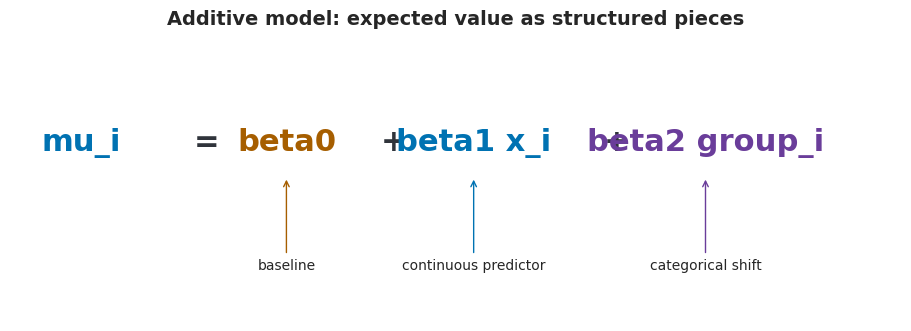

In [195]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

pieces = [
    ("mu_i", 0.08, COLORS["mean"]),
    ("=", 0.22, COLORS["observed"]),
    ("beta0", 0.31, COLORS["reference"]),
    ("+", 0.43, COLORS["observed"]),
    ("beta1 x_i", 0.52, COLORS["mean"]),
    ("+", 0.68, COLORS["observed"]),
    ("beta2 group_i", 0.78, COLORS["interaction"]),
]
for text, xpos, color in pieces:
    ax.text(xpos, 0.62, text, ha="center", va="center", fontsize=22, color=color, weight="bold")

ax.annotate("baseline", xy=(0.31, 0.50), xytext=(0.31, 0.18),
            arrowprops=dict(arrowstyle="->", color=COLORS["reference"]), ha="center")
ax.annotate("continuous predictor", xy=(0.52, 0.50), xytext=(0.52, 0.18),
            arrowprops=dict(arrowstyle="->", color=COLORS["mean"]), ha="center")
ax.annotate("categorical shift", xy=(0.78, 0.50), xytext=(0.78, 0.18),
            arrowprops=dict(arrowstyle="->", color=COLORS["interaction"]), ha="center")
ax.set_title("Additive model: expected value as structured pieces", fontsize=14, weight="bold")
plt.show()


### 9.1.04 Lecture 8 reminder: one slope, one mean line

Figure ID: F02. We begin with the familiar regression picture: a continuous
predictor changes the expected value smoothly.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, flipper_length_mm]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 82 seconds.
Default computed for conditional variable: flipper_length_mm


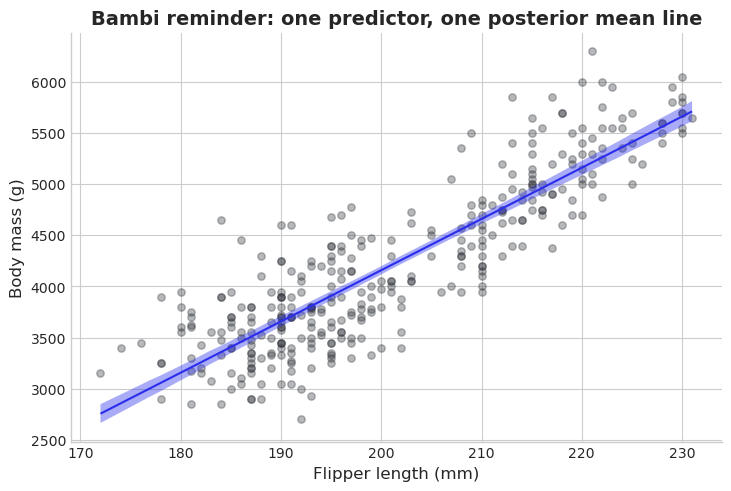

In [196]:
quick_flipper_model = bmb.Model(
    "body_mass_g ~ flipper_length_mm",
    data=penguins,
)
quick_flipper_idata = quick_flipper_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)

fig, ax = plt.subplots()
ax.scatter(
    penguins["flipper_length_mm"],
    penguins["body_mass_g"],
    s=28,
    alpha=0.35,
    color=COLORS["observed"],
)
bmb.interpret.plot_predictions(
    quick_flipper_model,
    quick_flipper_idata,
    conditional="flipper_length_mm",
    ax=ax,
)
style_axis(ax, "Bambi reminder: one predictor, one posterior mean line", LABELS["flipper_length_mm"], LABELS["body_mass_g"])
plt.show()


<a id="section-92"></a>
## 9.2 Categorical predictors

Categorical predictors are regression predictors too. The model still predicts
`mu_i`; the design matrix simply uses indicator columns instead of a continuous
measurement.


### 9.2.08 Raw body mass by species


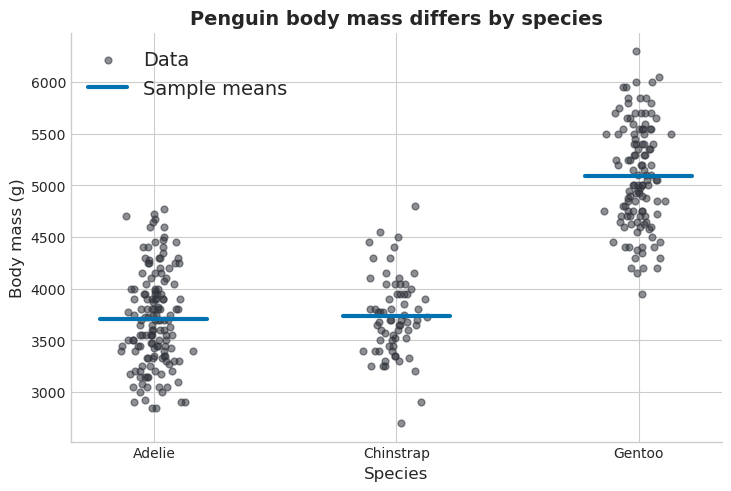

In [197]:
species_order = ["Adelie", "Chinstrap", "Gentoo"]
species_positions = np.arange(len(species_order))

fig, ax = plt.subplots()
for pos, species in zip(species_positions, species_order):
    values = penguins.loc[penguins["species"] == species, "body_mass_g"].to_numpy()
    jitter = rng.normal(0, 0.055, size=len(values))
    data_label = "Data" if pos == species_positions[0] else None
    mean_label = "Sample means" if pos == species_positions[0] else None
    ax.scatter(
        np.full(len(values), pos) + jitter,
        values,
        s=24,
        alpha=0.55,
        color=COLORS["observed"],
        label=data_label,
    )
    ax.plot(
        [pos - 0.22, pos + 0.22],
        [values.mean(), values.mean()],
        color=COLORS["mean"],
        lw=3,
        label=mean_label,
    )

ax.set_xticks(species_positions)
ax.set_xticklabels(species_order)
style_axis(ax, "Penguin body mass differs by species", "Species", LABELS["body_mass_g"])
ax.legend(frameon=False, loc="upper left")
plt.show()


### 9.2.09 Reference coding diagram


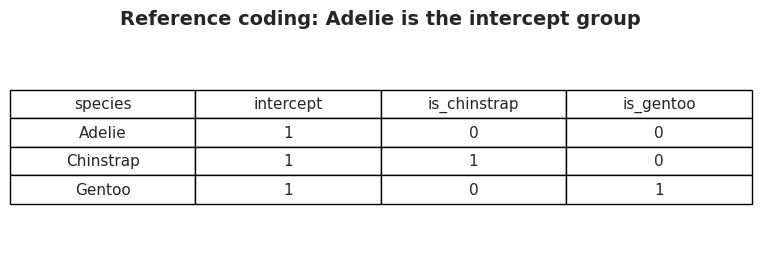

In [198]:
coding_table = pd.DataFrame(
    {
        "species": species_order,
        "intercept": [1, 1, 1],
        "is_chinstrap": [0, 1, 0],
        "is_gentoo": [0, 0, 1],
    }
)

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.axis("off")
table = ax.table(cellText=coding_table.values, colLabels=coding_table.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
ax.set_title("Reference coding: Adelie is the intercept group", fontsize=14, weight="bold")
plt.show()


### 9.2.11 Bambi species model: `body_mass ~ species`


In [199]:
penguins_species = penguins[["body_mass_g", "species"]].dropna().copy()
body_mass_species = penguins_species["body_mass_g"].to_numpy()
species_contrasts = ["Chinstrap", "Gentoo"]

mass_species_model = bmb.Model(
    "body_mass_g ~ species",
    data=penguins_species,
)
mass_species_model.build()

In [200]:
mass_species_design = mass_species_model.components["mu"].design.common.as_dataframe()
bambi_species_coefficients = mass_species_design.columns.to_list()

bambi_species_coding = (
    pd.concat(
        [
            penguins_species["species"].reset_index(drop=True),
            mass_species_design.reset_index(drop=True),
        ],
        axis=1,
    )
    .drop_duplicates()
    .assign(species=lambda data: pd.Categorical(data["species"], categories=species_order, ordered=True))
    .sort_values("species")
    .reset_index(drop=True)
)

for coefficient_name in bambi_species_coefficients:
    bambi_species_coding[coefficient_name] = bambi_species_coding[coefficient_name].astype(int)




**Bambi design-matrix coefficient names:** `Intercept`, `species[Chinstrap]`, `species[Gentoo]`

,species,Intercept,species[Chinstrap],species[Gentoo],expected_mean
0,Adelie,1,0,0,Intercept
1,Chinstrap,1,1,0,Intercept + species[Chinstrap]
2,Gentoo,1,0,1,Intercept + species[Gentoo]


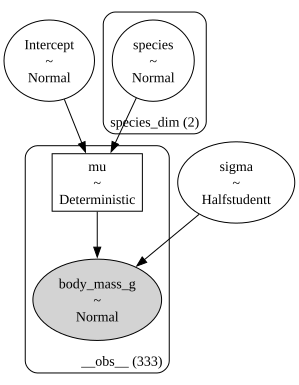

In [201]:
def describe_expected_mean(row):
    active_terms = [
        coefficient_name
        for coefficient_name in bambi_species_coefficients
        if row[coefficient_name] != 0
    ]
    return " + ".join(active_terms)


bambi_species_coding["expected_mean"] = bambi_species_coding.apply(describe_expected_mean, axis=1)

display(Markdown("**Bambi design-matrix coefficient names:** " + ", ".join(f"`{name}`" for name in bambi_species_coefficients)))
display(bambi_species_coding)

try:
    display(mass_species_model.graph())
except Exception as exc:
    print(mass_species_model)
    print(exc)


### 9.2.12 Sampling diagnostics and posterior summary


In [202]:
idata_mass_species = mass_species_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
mass_species_model.predict(idata_mass_species, kind="response", inplace=True, random_seed=RANDOM_SEED)

check_diagnostics(idata_mass_species, ["Intercept", "species", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, species]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 93 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,3706.960,38.391,3631.540,3776.370,4745.0,3458.0,1.0
species[Chinstrap],25.296,67.623,-98.350,153.913,4097.0,3464.0,1.0
species[Gentoo],1385.146,57.599,1279.879,1491.911,4418.0,3295.0,1.0
sigma,461.768,18.123,427.434,495.043,5823.0,3255.0,1.0


### 9.2.13 Posterior group means


,mean,sd,hdi_3%,hdi_97%
mean_body_mass[Adelie],3706.960,38.391,3631.540,3776.37
mean_body_mass[Chinstrap],3732.256,55.827,3624.600,3836.94
mean_body_mass[Gentoo],5092.106,42.158,5011.514,5167.22


Default computed for conditional variable: species


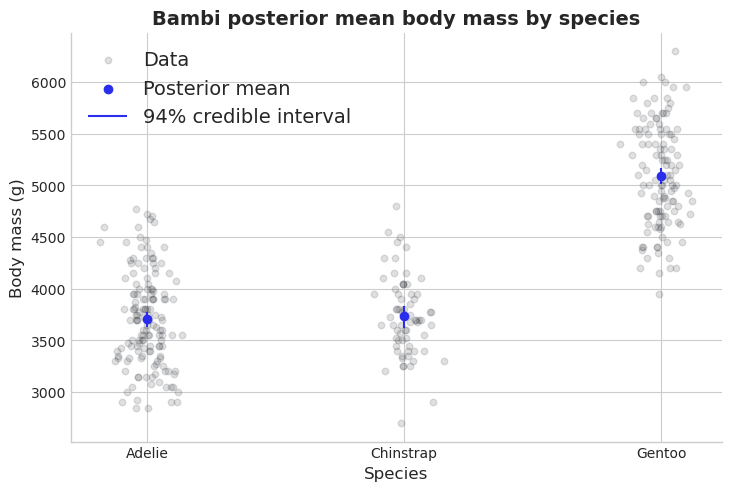

In [203]:
posterior_species = idata_mass_species.posterior
beta0_draws = posterior_species["Intercept"]
beta_species_draws = posterior_species["species"]

adelie_mean = beta0_draws
chinstrap_mean = beta0_draws + beta_species_draws.sel(species_dim="Chinstrap", drop=True)
gentoo_mean = beta0_draws + beta_species_draws.sel(species_dim="Gentoo", drop=True)

species_mean_draws = xr.concat(
    [adelie_mean, chinstrap_mean, gentoo_mean],
    dim=pd.Index(species_order, name="species"),
)

summary_species_means = az.summary(species_mean_draws.to_dataset(name="mean_body_mass"), var_names=["mean_body_mass"])
display(summary_species_means[["mean", "sd", "hdi_3%", "hdi_97%"]])

fig, ax = plt.subplots()
group_mean_rng = np.random.default_rng(RANDOM_SEED + 9213)
for pos, species in zip(species_positions, species_order):
    values = penguins_species.loc[penguins_species["species"] == species, "body_mass_g"].to_numpy()
    jitter = group_mean_rng.normal(0, 0.055, size=len(values))
    ax.scatter(
        np.full(len(values), pos) + jitter,
        values,
        s=22,
        alpha=0.15,
        color=COLORS["observed"],
        label="Data" if pos == species_positions[0] else None,
        zorder=1,
    )

bambi_artist_start = len(ax.collections)
bmb.interpret.plot_predictions(
    mass_species_model,
    idata_mass_species,
    conditional="species",
    legend=False,
    ax=ax,
)

bambi_artists = ax.collections[bambi_artist_start:]
bambi_artists[0].set_label("Posterior mean")
bambi_artists[1].set_label("94% credible interval")

style_axis(ax, "Bambi posterior mean body mass by species", "Species", LABELS["body_mass_g"])
ax.legend(frameon=False, loc="upper left")
plt.show()


### 9.2.14 Coefficient interpretation figure


,mean,sd,hdi_3%,hdi_97%
species[Chinstrap],25.296,67.623,-98.350,153.913
species[Gentoo],1385.146,57.599,1279.879,1491.911


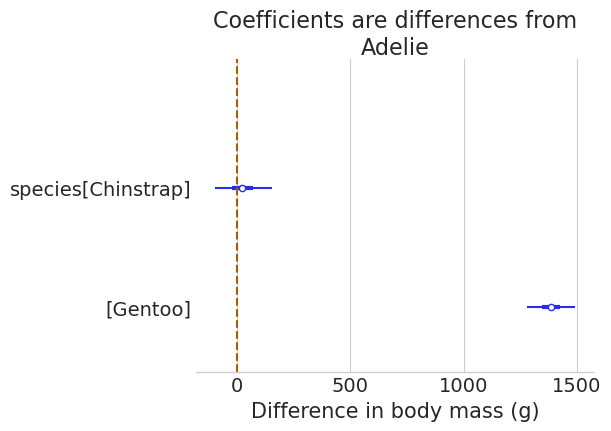

In [204]:
coef_summary = az.summary(idata_mass_species, var_names=["species"])
display(coef_summary[["mean", "sd", "hdi_3%", "hdi_97%"]])

ax = az.plot_forest(
    idata_mass_species,
    var_names=["species"],
    combined=True,
    hdi_prob=0.94,
)[0]
ax.axvline(0, color=COLORS["reference"], lw=1.5, ls="--")
ax.set_title("Coefficients are differences from Adelie")
ax.set_xlabel("Difference in body mass (g)")
plt.show()


### 9.2.15 One-way ANOVA as regression schematic


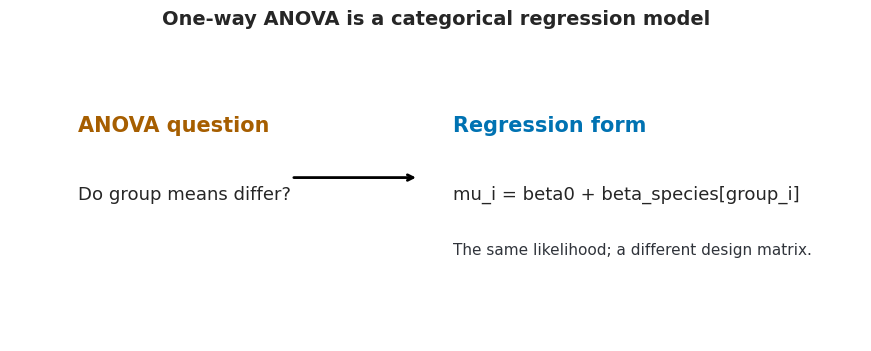

In [205]:
fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.axis("off")
ax.text(0.08, 0.68, "ANOVA question", fontsize=15, weight="bold", color=COLORS["reference"])
ax.text(0.08, 0.46, "Do group means differ?", fontsize=13)
ax.annotate("", xy=(0.48, 0.53), xytext=(0.33, 0.53), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.52, 0.68, "Regression form", fontsize=15, weight="bold", color=COLORS["mean"])
ax.text(0.52, 0.46, "mu_i = beta0 + beta_species[group_i]", fontsize=13)
ax.text(0.52, 0.28, "The same likelihood; a different design matrix.", fontsize=11, color=COLORS["observed"])
ax.set_title("One-way ANOVA is a categorical regression model", fontsize=14, weight="bold")
plt.show()


### 9.2.16 Add sex: `body_mass ~ species + sex`


In [206]:
penguins_species_sex = penguins[["body_mass_g", "species", "sex"]].dropna().copy()
body_mass_species_sex = penguins_species_sex["body_mass_g"].to_numpy()
additive_terms = ["Chinstrap - Adelie", "Gentoo - Adelie", "male - female"]

mass_species_sex_model = bmb.Model(
    "body_mass_g ~ species + sex",
    data=penguins_species_sex,
)


In [207]:
idata_mass_species_sex = mass_species_sex_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
mass_species_sex_model.predict(idata_mass_species_sex, kind="response", inplace=True, random_seed=RANDOM_SEED)

check_diagnostics(idata_mass_species_sex, ["Intercept", "species", "sex", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, species, sex]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 126 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,3372.215,31.766,3312.757,3430.225,4615.0,3391.0,1.0
species[Chinstrap],27.073,46.341,-56.822,117.919,3764.0,3362.0,1.0
species[Gentoo],1377.267,39.643,1302.282,1450.973,4247.0,3721.0,1.0
sex[male],667.810,35.333,604.802,736.241,5164.0,3227.0,1.0
sigma,317.784,12.545,295.920,343.420,5810.0,3509.0,1.0


### 9.2.17 Posterior predictive check


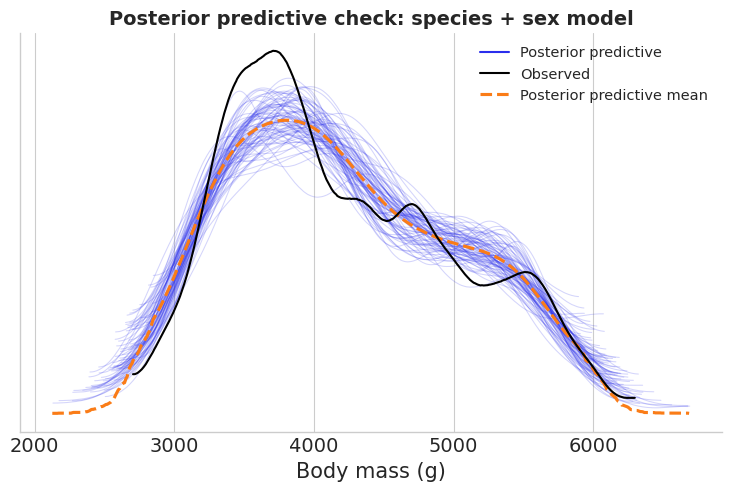

In [208]:
ax = az.plot_ppc(idata_mass_species_sex, var_names=["body_mass_g"], num_pp_samples=80, kind="kde")
ax.set_title("Posterior predictive check: species + sex model", fontsize=14, weight="bold")
ax.set_xlabel(LABELS["body_mass_g"])
plt.show()


### 9.2.18 Posterior means for species + sex


Default computed for conditional variable: species, sex


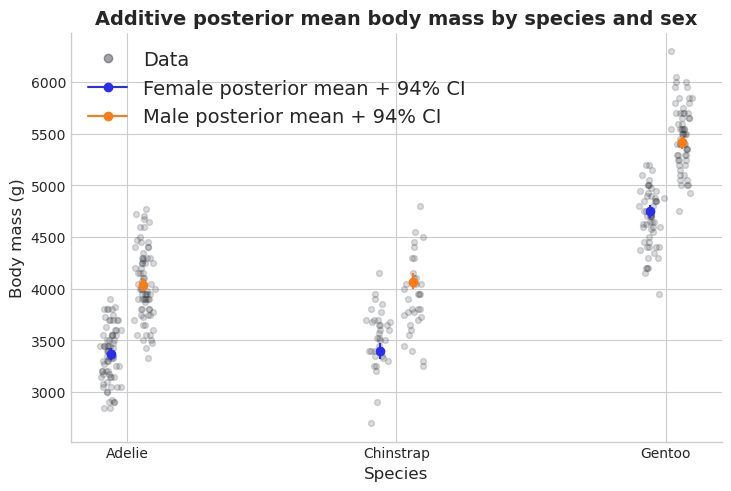

In [209]:
from matplotlib.lines import Line2D

sex_order = ["female", "male"]

fig, ax = plt.subplots()
bambi_artist_start = len(ax.collections)
bmb.interpret.plot_predictions(
    mass_species_sex_model,
    idata_mass_species_sex,
    conditional=["species", "sex"],
    subplot_kwargs={"main": "species", "group": "sex"},
    legend=False,
    ax=ax,
)

bambi_artists = ax.collections[bambi_artist_start:]
posterior_mean_artists = [
    artist
    for artist in bambi_artists
    if type(artist).__name__ == "PathCollection"
]

species_sex_x_positions = {
    sex: dict(zip(species_order, artist.get_offsets()[:, 0]))
    for sex, artist in zip(sex_order, posterior_mean_artists)
}

species_sex_rng = np.random.default_rng(RANDOM_SEED + 9218)
for species in species_order:
    for sex in sex_order:
        values = penguins_species_sex.loc[
            (penguins_species_sex["species"] == species)
            & (penguins_species_sex["sex"] == sex),
            "body_mass_g",
        ].to_numpy()
        jitter = species_sex_rng.normal(0, 0.018, size=len(values))
        x_center = species_sex_x_positions[sex][species]
        ax.scatter(
            np.full(len(values), x_center) + jitter,
            values,
            s=18,
            alpha=0.18,
            color=COLORS["observed"],
            zorder=1,
        )

for artist in bambi_artists:
    artist.set_zorder(3)

female_color = posterior_mean_artists[0].get_facecolor()[0]
male_color = posterior_mean_artists[1].get_facecolor()[0]
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=COLORS["observed"],
        alpha=0.45,
        markersize=6,
        label="Data",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        color=female_color,
        markersize=6,
        label="Female posterior mean + 94% CI",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        color=male_color,
        markersize=6,
        label="Male posterior mean + 94% CI",
    ),
]

style_axis(
    ax,
    "Additive posterior mean body mass by species and sex",
    "Species",
    LABELS["body_mass_g"],
)
ax.legend(handles=legend_handles, frameon=False, loc="upper left")
plt.show()


Default computed for conditional variable: species


Text(0.5, 1.0, 'Difference between males and females by species')

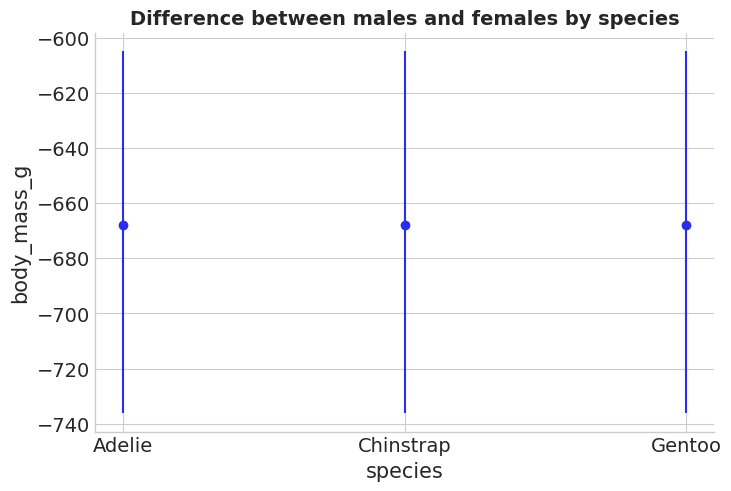

In [210]:
bmb.interpret.plot_comparisons(model=mass_species_sex_model, idata=idata_mass_species_sex, 
                              contrast={"sex": ["male", "female"]},
                              conditional="species") 
plt.title("Difference between males and females by species", fontsize=14, weight="bold")

Default computed for conditional variable: sex


Text(0.5, 1.0, 'Difference between Adelie and Gentoo by sex')

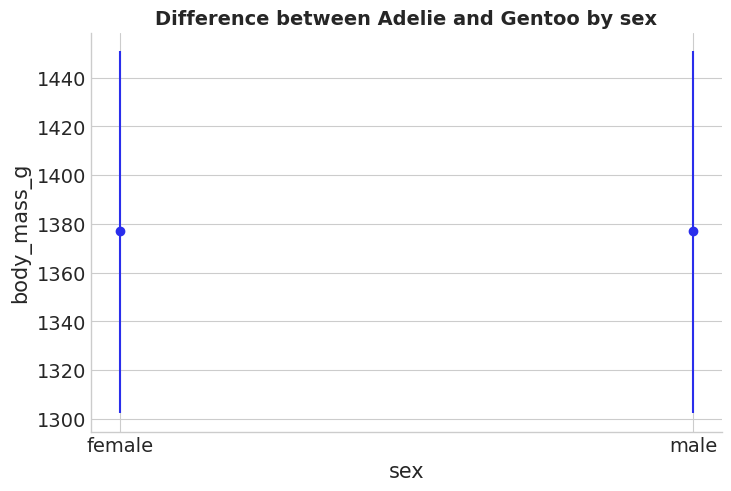

In [211]:
bmb.interpret.plot_comparisons(model=mass_species_sex_model, idata=idata_mass_species_sex, 
                              contrast={"species": ["Adelie", "Gentoo"]},
                              conditional="sex") 
plt.title("Difference between Adelie and Gentoo by sex", fontsize=14, weight="bold")

<a id="section-93"></a>
## 9.3 Interactions

An interaction asks whether one predictor changes the effect of another predictor.
The model is still a Normal likelihood; the mean structure now contains a product
term or a set of cell means.

The three focal model statements in this section are:

- `body_mass ~ flipper_length * bill_length`
- `body_mass ~ species * sex`
- `len ~ dose * supp`


### 9.3.20 Weak continuous interaction: penguins


In [212]:
penguins_cont = penguins[["body_mass_g", "flipper_length_mm", "bill_length_mm"]].dropna().copy()
body_mass_cont = penguins_cont["body_mass_g"].to_numpy()


In [213]:
bill_levels = {
    "Short bill": penguins_cont["bill_length_mm"].quantile(0.15),
    "Average bill": penguins_cont["bill_length_mm"].mean(),
    "Long bill": penguins_cont["bill_length_mm"].quantile(0.85),
}
bill_level_values = list(bill_levels.values())
bill_level_labels = [
    f"{label} ({value:.1f} mm)"
    for label, value in bill_levels.items()
]
bill_level_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][: len(bill_levels)]

short_average_cut = np.mean([bill_levels["Short bill"], bill_levels["Average bill"]])
average_long_cut = np.mean([bill_levels["Average bill"], bill_levels["Long bill"]])
penguins_cont["bill_length_group"] = pd.cut(
    penguins_cont["bill_length_mm"],
    bins=[-np.inf, short_average_cut, average_long_cut, np.inf],
    labels=list(bill_levels),
)

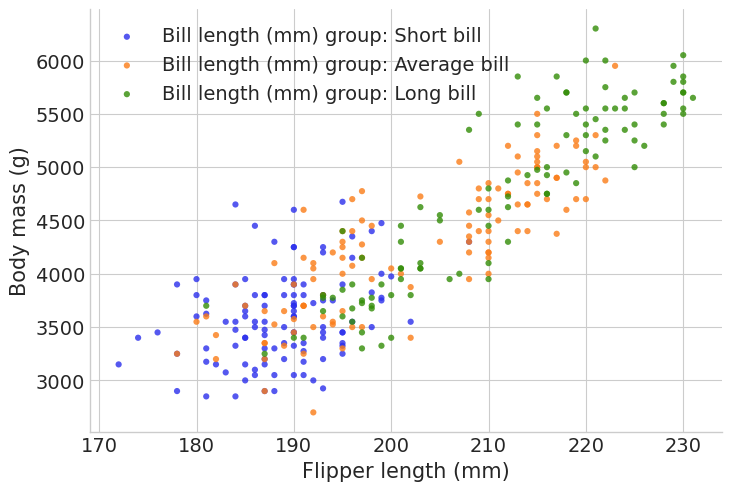

In [214]:
fig,ax = plt.subplots()

for label, color in zip(bill_levels, bill_level_colors):
    bill_group_data = penguins_cont.loc[penguins_cont["bill_length_group"] == label]
    ax.scatter(
        bill_group_data["flipper_length_mm"],
        bill_group_data["body_mass_g"],
        s=20,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=1,
        label=LABELS["bill_length_mm"] + f" group: {label}"
    )
ax.set_xlabel(LABELS["flipper_length_mm"])
ax.set_ylabel(LABELS["body_mass_g"])
ax.legend(frameon=False, loc="upper left")

### 9.3.19 Causal sketch: latent body size as a common driver

```mermaid
flowchart 
    size["Latent body size"]
    flipper["Flipper length<br/>(mm)"]
    bill["Bill length<br/>(mm)"]
    mass["Body mass<br/>(g)"]

    size --> flipper
    size --> bill
    size --> mass
```

- This DAG encodes a **shared-cause** structure: overall size influences all three observed measures.
- Under this view, association between flipper length and bill length can arise because both are downstream of body size.


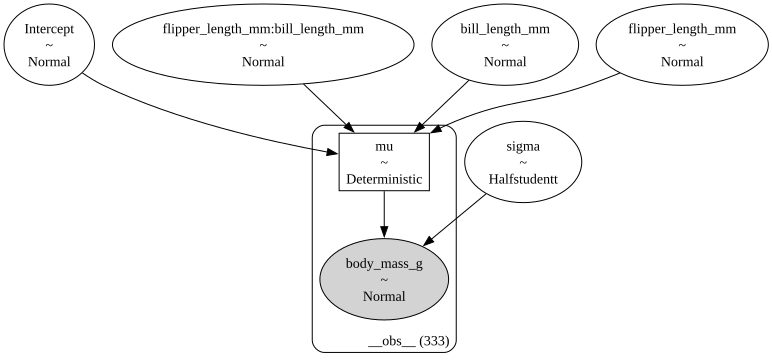

In [215]:
mass_flipper_bill_model = bmb.Model(
    "body_mass_g ~ flipper_length_mm * bill_length_mm",
    data=penguins_cont,
)
mass_flipper_bill_model.build()

try:
    display(mass_flipper_bill_model.graph())
except Exception as exc:
    print(mass_flipper_bill_model)
    print(exc)


In [216]:
idata_mass_flipper_bill = mass_flipper_bill_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
mass_flipper_bill_model.predict(idata_mass_flipper_bill, kind="response", inplace=True, random_seed=RANDOM_SEED)

check_diagnostics(
    idata_mass_flipper_bill,
    ["Intercept", "flipper_length_mm", "bill_length_mm", "flipper_length_mm:bill_length_mm", "sigma"],
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, flipper_length_mm, bill_length_mm, flipper_length_mm:bill_length_mm]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 121 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,3621.898,2803.673,-1871.988,8563.181,962.0,1547.0,1.0
flipper_length_mm,0.424,14.426,-25.400,28.737,967.0,1544.0,1.0
bill_length_mm,-200.051,60.561,-311.136,-84.626,951.0,1541.0,1.0
flipper_length_mm:bill_length_mm,1.046,0.308,0.449,1.598,945.0,1528.0,1.0
sigma,387.680,15.458,357.173,415.561,2231.0,2154.0,1.0


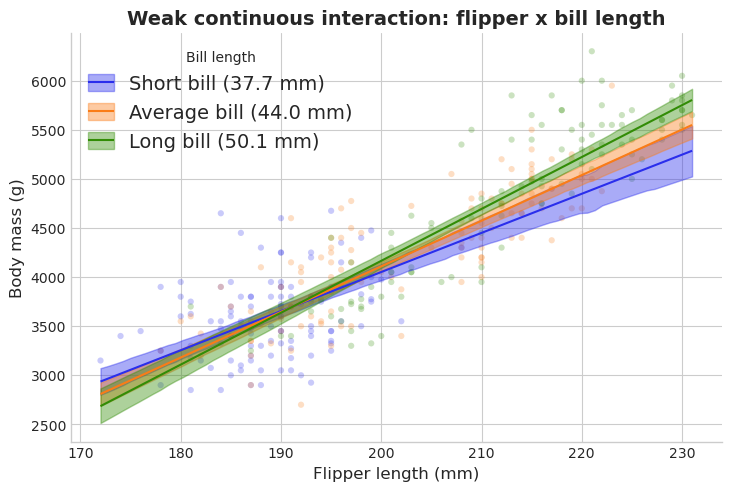

In [217]:


fig, ax = plt.subplots()
for label, color in zip(bill_levels, bill_level_colors):
    bill_group_data = penguins_cont.loc[penguins_cont["bill_length_group"] == label]
    ax.scatter(
        bill_group_data["flipper_length_mm"],
        bill_group_data["body_mass_g"],
        s=20,
        alpha=0.25,
        color=color,
        edgecolor="none",
        zorder=1,
    )

bmb.interpret.plot_predictions(
    mass_flipper_bill_model,
    idata_mass_flipper_bill,
    conditional={
        "flipper_length_mm": np.linspace(
            penguins_cont["flipper_length_mm"].min(),
            penguins_cont["flipper_length_mm"].max(),
            80,
        ),
        "bill_length_mm": bill_level_values,
    },
    ax=ax,
)

legend = ax.get_legend()
if legend is not None:
    legend.set_title("Bill length")
    for legend_text, label in zip(legend.get_texts(), bill_level_labels):
        legend_text.set_text(label)

style_axis(
    ax,
    "Weak continuous interaction: flipper x bill length",
    LABELS["flipper_length_mm"],
    LABELS["body_mass_g"],
)
plt.show()


### 9.3.21 Posterior interaction parameter

The interaction coefficient is small in natural units, so we also place it on a standardized scale. Here the standardized coefficient is computed from posterior draws by multiplying by the observed standard deviations of the two predictors and dividing by the observed standard deviation of the outcome.


In [218]:
idata_mass_flipper_bill

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

array([<Axes: title={'center': 'flipper_length_mm'}>,
       <Axes: title={'center': 'bill_length_mm'}>,
       <Axes: title={'center': 'flipper_length_mm:bill_length_mm'}>],
      dtype=object)

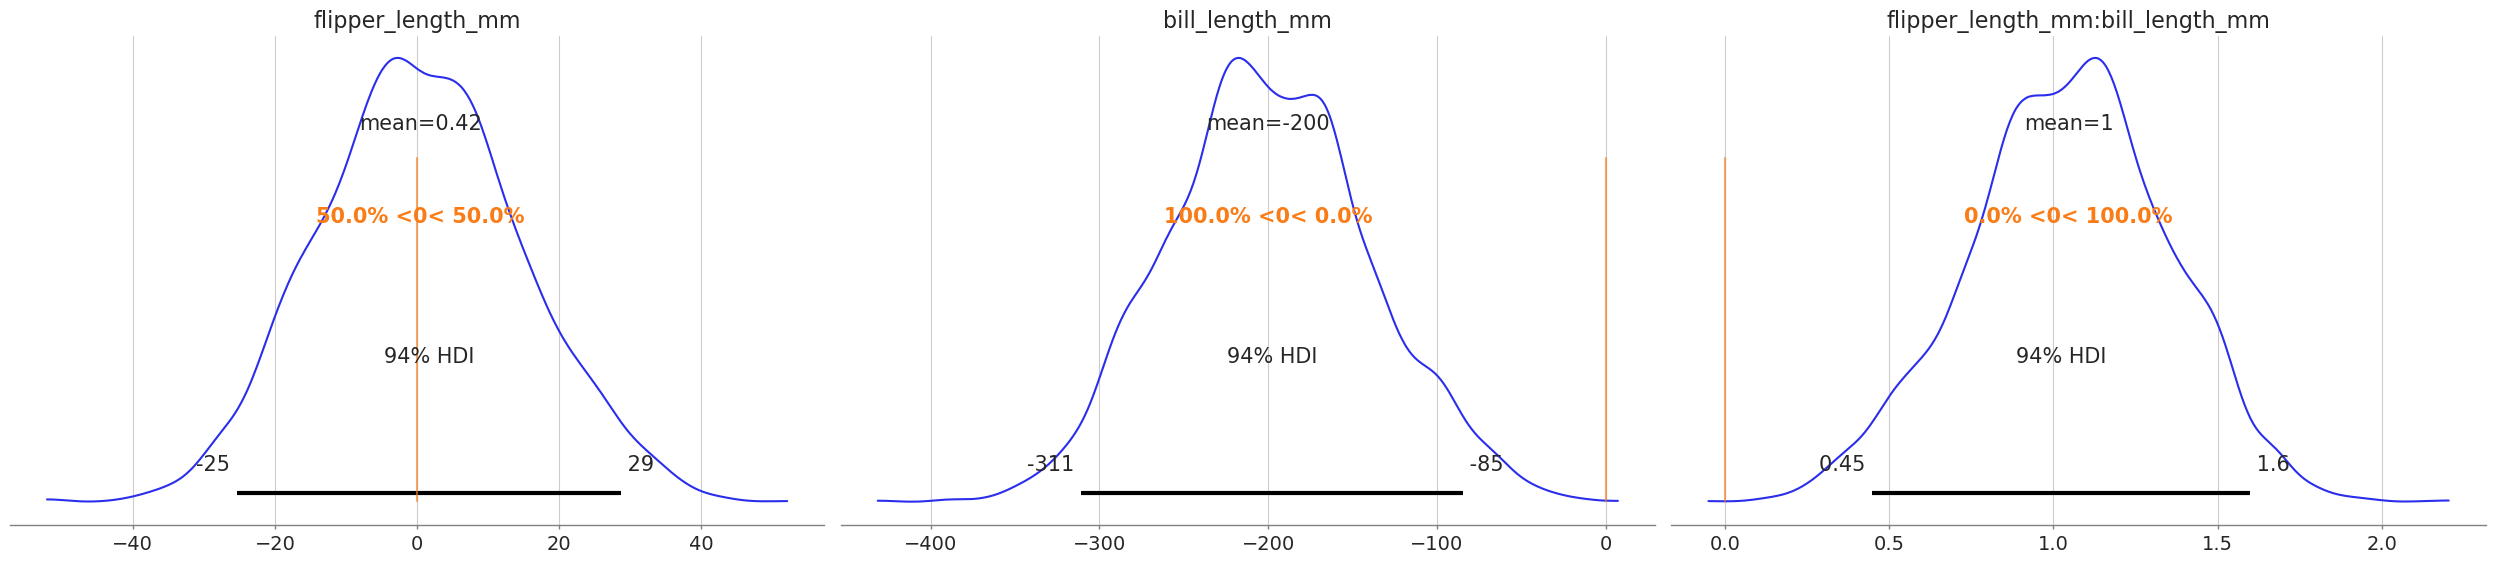

In [219]:
az.plot_posterior(idata_mass_flipper_bill, 
                  var_names=["flipper_length_mm", "bill_length_mm", "flipper_length_mm:bill_length_mm"], hdi_prob=0.94,
                  ref_val=0)

In [220]:
flipper_length_std = penguins_cont["flipper_length_mm"].std()
bill_length_std = penguins_cont["bill_length_mm"].std()
body_mass_std = penguins_cont["body_mass_g"].std()

posterior = idata_mass_flipper_bill.posterior
posterior["flipper_length_std"] = posterior["flipper_length_mm"] * flipper_length_std / body_mass_std
posterior["bill_length_std"] = posterior["bill_length_mm"] * bill_length_std / body_mass_std
posterior["flipper_bill_interaction_std"] = posterior["flipper_length_mm:bill_length_mm"] * (flipper_length_std * bill_length_std) / body_mass_std


array([<Axes: title={'center': 'flipper_length_std'}>,
       <Axes: title={'center': 'bill_length_std'}>,
       <Axes: title={'center': 'flipper_bill_interaction_std'}>],
      dtype=object)

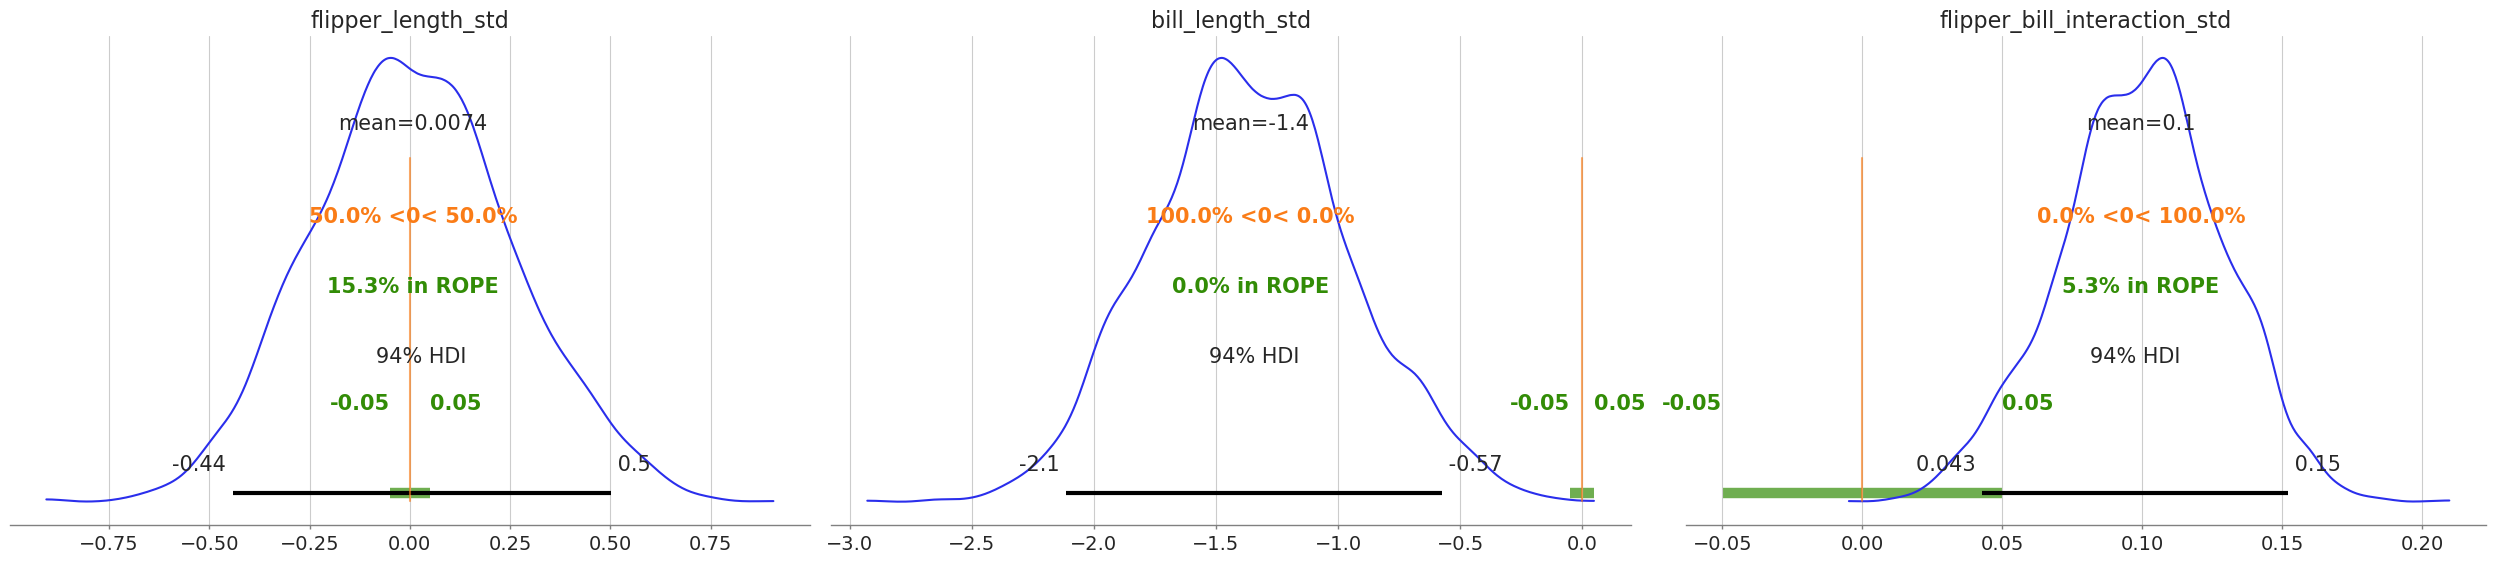

In [221]:
az.plot_posterior(idata_mass_flipper_bill, 
                  var_names=["flipper_length_std", "bill_length_std", "flipper_bill_interaction_std"], hdi_prob=0.94, 
                  ref_val=0, rope=(-0.05, 0.05),)

array([[<Axes: ylabel='bill_length_std'>, <Axes: >],
       [<Axes: xlabel='flipper_length_std', ylabel='flipper_bill_interaction_std'>,
        <Axes: xlabel='bill_length_std'>]], dtype=object)

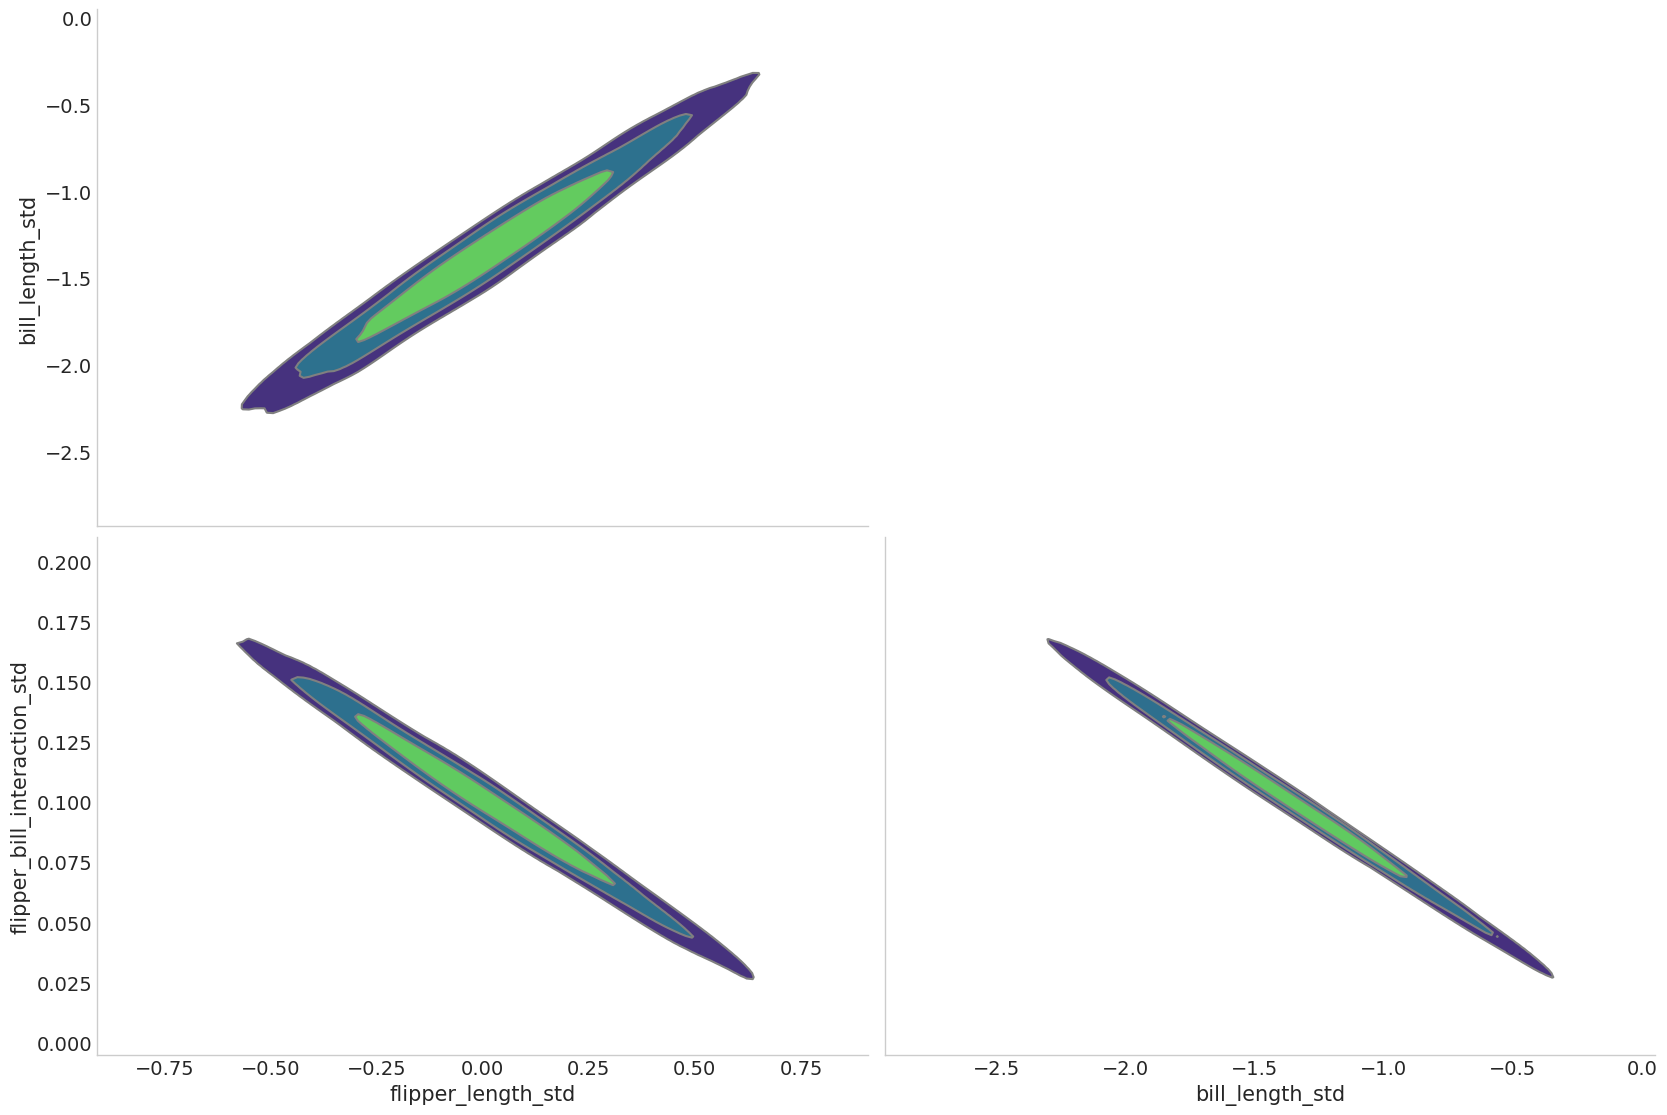

In [222]:
az.plot_pair(
    posterior,
    var_names=["flipper_length_std", "bill_length_std", "flipper_bill_interaction_std"],
    kind="kde",

)

### 9.3.24 Species x sex interaction plot


In [223]:
cell_labels = [f"{species}, {sex}" for species in species_order for sex in ["female", "male"]]
penguins_cell = penguins[["body_mass_g", "species", "sex"]].dropna().copy()
penguins_cell["species_sex"] = [f"{row.species}, {row.sex}" for row in penguins_cell.itertuples()]
body_mass_cell = penguins_cell["body_mass_g"].to_numpy()

mass_species_sex_interaction_model = bmb.Model(
    "body_mass_g ~ 0 + species:sex",
    data=penguins_cell,
)
mass_species_sex_interaction_model.build()


In [224]:
idata_mass_species_sex_interaction = mass_species_sex_interaction_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
mass_species_sex_interaction_model.predict(
    idata_mass_species_sex_interaction,
    kind="response",
    inplace=True,
    random_seed=RANDOM_SEED,
)

check_diagnostics(idata_mass_species_sex_interaction, ["species:sex", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, species:sex]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 83 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
"species:sex[Adelie, female]",3368.289,36.171,3299.038,3436.406,6328.0,3365.0,1.0
"species:sex[Adelie, male]",4043.687,36.972,3972.448,4111.917,6481.0,3086.0,1.0
"species:sex[Chinstrap, female]",3526.981,54.733,3427.233,3630.533,5043.0,3009.0,1.0
"species:sex[Chinstrap, male]",3938.505,53.760,3835.438,4040.343,4726.0,3107.0,1.0
"species:sex[Gentoo, female]",4680.625,41.294,4605.525,4759.418,6112.0,3245.0,1.0
"species:sex[Gentoo, male]",5485.206,40.831,5409.889,5561.664,5077.0,3319.0,1.0
sigma,310.445,12.107,287.822,333.716,4920.0,3082.0,1.0


In [225]:
idata_mass_species_sex_interaction.posterior

<xarray.Dataset> Size: 11MB
Dimensions:          (chain: 4, draw: 1000, species:sex_dim: 6, __obs__: 333)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * species:sex_dim  (species:sex_dim) <U17 408B 'Adelie, female' ... 'Gentoo...
  * __obs__          (__obs__) int64 3kB 0 1 2 3 4 5 ... 327 328 329 330 331 332
Data variables:
    sigma            (chain, draw) float64 32kB 307.4 299.9 ... 307.9 301.8
    species:sex      (chain, draw, species:sex_dim) float64 192kB 3.365e+03 ....
    mu               (chain, draw, __obs__) float64 11MB 4.014e+03 ... 3.535e+03
Attributes:
    created_at:                  2026-06-10T04:40:11.953142+00:00
    arviz_version:               0.23.4
    inference_library:           pymc
    inference_library_version:   5.28.1
    sampling_time:               82.69041609764099
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.17.2

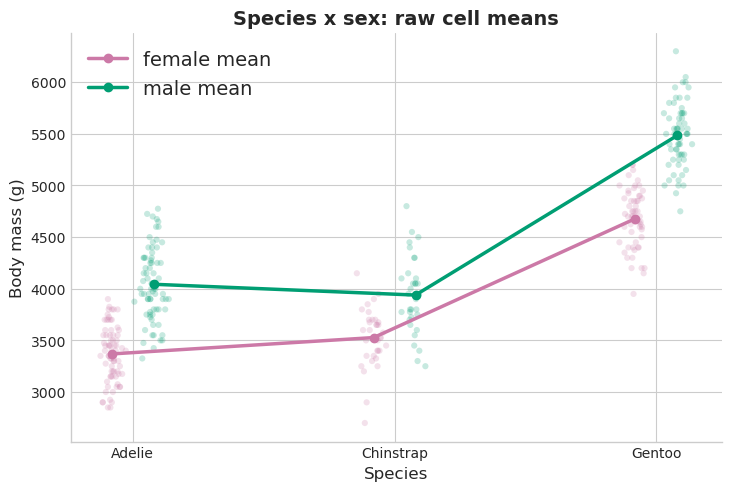

In [226]:
raw_cell_means = penguins_cell.groupby(["species", "sex"], observed=True)["body_mass_g"].mean().unstack()

sex_offsets = {"female": -0.08, "male": 0.08}
sex_colors = {"female": COLORS["female"], "male": COLORS["male"]}
species_position_lookup = dict(zip(species_order, species_positions))

fig, ax = plt.subplots()
species_sex_rng = np.random.default_rng(RANDOM_SEED + 9324)
for sex in ["female", "male"]:
    sex_data = penguins_cell.loc[penguins_cell["sex"] == sex]
    x_positions = sex_data["species"].map(species_position_lookup).astype(float).to_numpy()
    jitter = species_sex_rng.normal(0, 0.025, size=len(sex_data))
    ax.scatter(
        x_positions + sex_offsets[sex] + jitter,
        sex_data["body_mass_g"],
        s=20,
        alpha=0.22,
        color=sex_colors[sex],
        edgecolor="none",
        zorder=1,
    )

ax.plot(
    species_positions + sex_offsets["female"],
    raw_cell_means["female"].reindex(species_order),
    marker="o",
    color=COLORS["female"],
    lw=2.5,
    label="female mean",
    zorder=3,
)
ax.plot(
    species_positions + sex_offsets["male"],
    raw_cell_means["male"].reindex(species_order),
    marker="o",
    color=COLORS["male"],
    lw=2.5,
    label="male mean",
    zorder=3,
)
ax.set_xticks(species_positions)
ax.set_xticklabels(species_order)
style_axis(ax, "Species x sex: raw cell means", "Species", LABELS["body_mass_g"])
ax.legend(frameon=False)
plt.show()


### 9.3.25 Posterior cell means


,mean,sd,hdi_3%,hdi_97%
"cell_mean_body_mass[Adelie, female]",3368.289,36.171,3299.038,3436.406
"cell_mean_body_mass[Adelie, male]",4043.687,36.972,3972.448,4111.917
"cell_mean_body_mass[Chinstrap, female]",3526.981,54.733,3427.233,3630.533
"cell_mean_body_mass[Chinstrap, male]",3938.505,53.760,3835.438,4040.343
"cell_mean_body_mass[Gentoo, female]",4680.625,41.294,4605.525,4759.418
"cell_mean_body_mass[Gentoo, male]",5485.206,40.831,5409.889,5561.664


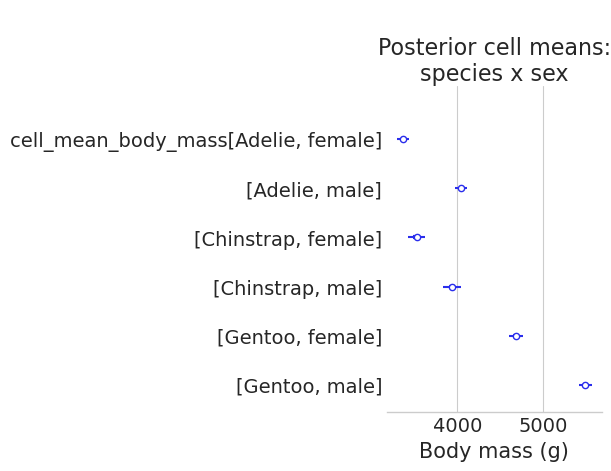

In [227]:
posterior_cell = idata_mass_species_sex_interaction.posterior["species:sex"].rename({"species:sex_dim": "cell"})
cell_mean = posterior_cell.mean(("chain", "draw")).to_pandas()
cell_hdi = az.hdi(posterior_cell, hdi_prob=0.94).to_array().squeeze().transpose("cell", "hdi").to_pandas()

cell_mean_summary = az.summary(
    posterior_cell.to_dataset(name="cell_mean_body_mass"),
    var_names=["cell_mean_body_mass"],
)
display(cell_mean_summary[["mean", "sd", "hdi_3%", "hdi_97%"]])

ax = az.plot_forest(
    posterior_cell.to_dataset(name="cell_mean_body_mass"),
    var_names=["cell_mean_body_mass"],
    combined=True,
    hdi_prob=0.94,
)[0]
ax.set_title("Posterior cell means: species x sex")
ax.set_xlabel(LABELS["body_mass_g"])
plt.show()


### 9.3.26 Interaction contrasts


,mean,sd,hdi_3%,hdi_97%
interaction_contrast[Chinstrap vs Adelie],-263.875,89.544,-424.947,-94.415
interaction_contrast[Gentoo vs Adelie],129.183,78.651,-10.241,280.656


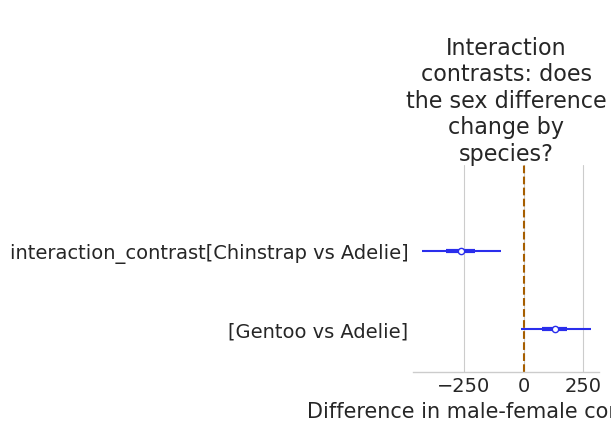

In [228]:
def cell_draw(label):
    return posterior_cell.sel(cell=label)


male_female_by_species = {
    species: cell_draw(f"{species}, male") - cell_draw(f"{species}, female")
    for species in species_order
}
interaction_contrasts = xr.concat(
    [
        male_female_by_species["Chinstrap"] - male_female_by_species["Adelie"],
        male_female_by_species["Gentoo"] - male_female_by_species["Adelie"],
    ],
    dim=pd.Index(["Chinstrap vs Adelie", "Gentoo vs Adelie"], name="contrast"),
)

contrast_summary = az.summary(interaction_contrasts.to_dataset(name="interaction_contrast"), var_names=["interaction_contrast"])
display(contrast_summary[["mean", "sd", "hdi_3%", "hdi_97%"]])

ax = az.plot_forest(
    interaction_contrasts.to_dataset(name="interaction_contrast"),
    var_names=["interaction_contrast"],
    combined=True,
    hdi_prob=0.94,
)[0]
ax.axvline(0, color=COLORS["reference"], ls="--")
ax.set_title("Interaction contrasts: does the sex difference change by species?")
ax.set_xlabel("Difference in male-female contrast (g)")
plt.show()


### 9.3.30 ToothGrowth dose-response interaction


In [229]:
tooth = toothgrowth[["len", "dose", "supp"]].dropna().copy()
len_tooth = tooth["len"].to_numpy()


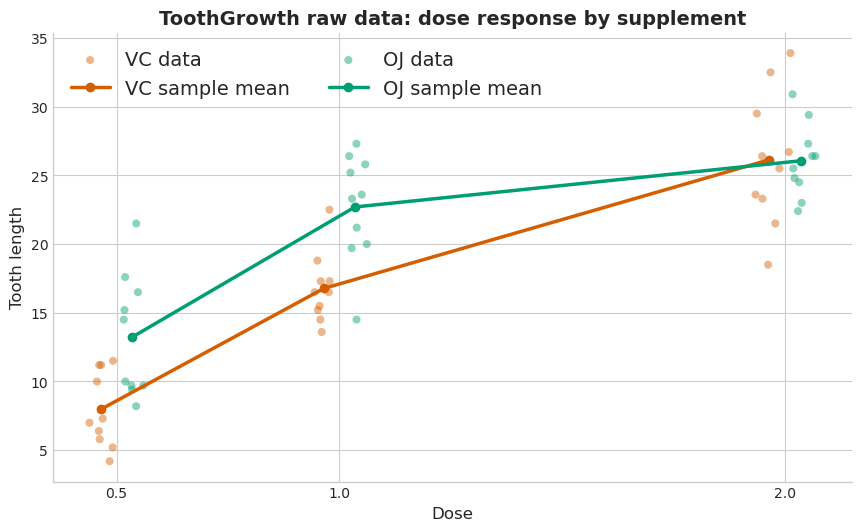

In [230]:
supp_colors = {"VC": COLORS["contrast"], "OJ": COLORS["predictive"]}
supp_offsets = {"VC": -0.035, "OJ": 0.035}

fig, ax = plt.subplots(figsize=(8.5, 5.2))
tooth_rng = np.random.default_rng(RANDOM_SEED + 9330)

for supp, color in supp_colors.items():
    supp_data = tooth.loc[tooth["supp"] == supp]
    jitter = tooth_rng.normal(0, 0.018, size=len(supp_data))
    ax.scatter(
        supp_data["dose"] + supp_offsets[supp] + jitter,
        supp_data["len"],
        s=34,
        alpha=0.45,
        color=color,
        edgecolor="none",
        label=f"{supp} data",
        zorder=1,
    )

    supp_means = (
        supp_data.groupby("dose", observed=True)["len"]
        .mean()
        .sort_index()
    )
    ax.plot(
        supp_means.index + supp_offsets[supp],
        supp_means.values,
        marker="o",
        lw=2.5,
        color=color,
        label=f"{supp} sample mean",
        zorder=3,
    )

style_axis(ax, "ToothGrowth raw data: dose response by supplement", LABELS["dose"], LABELS["len"])
ax.set_xticks(sorted(tooth["dose"].unique()))
ax.legend(frameon=False, ncol=2, loc="upper left")
plt.show()


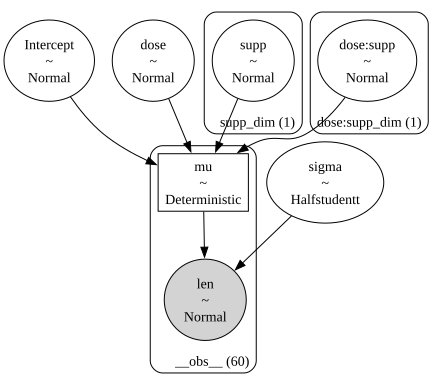

In [231]:
tooth_dose_supp_model = bmb.Model(
    "len ~ dose * supp",
    data=tooth,
)
tooth_dose_supp_model.build()

try:
    display(tooth_dose_supp_model.graph())
except Exception as exc:
    print(tooth_dose_supp_model)
    print(exc)


In [232]:
idata_tooth_dose_supp = tooth_dose_supp_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
tooth_dose_supp_model.predict(idata_tooth_dose_supp, kind="response", inplace=True, random_seed=RANDOM_SEED)

check_diagnostics(idata_tooth_dose_supp, ["Intercept", "dose", "supp", "dose:supp", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, dose, supp, dose:supp]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,3.340,1.643,0.255,6.372,2060.0,2481.0,1.0
dose,11.683,1.232,9.325,13.946,1952.0,2718.0,1.0
supp[OJ],8.182,2.320,3.841,12.365,1618.0,2229.0,1.0
dose:supp[OJ],-3.841,1.747,-6.996,-0.533,1478.0,1902.0,1.0
sigma,4.163,0.403,3.439,4.909,3323.0,2731.0,1.0


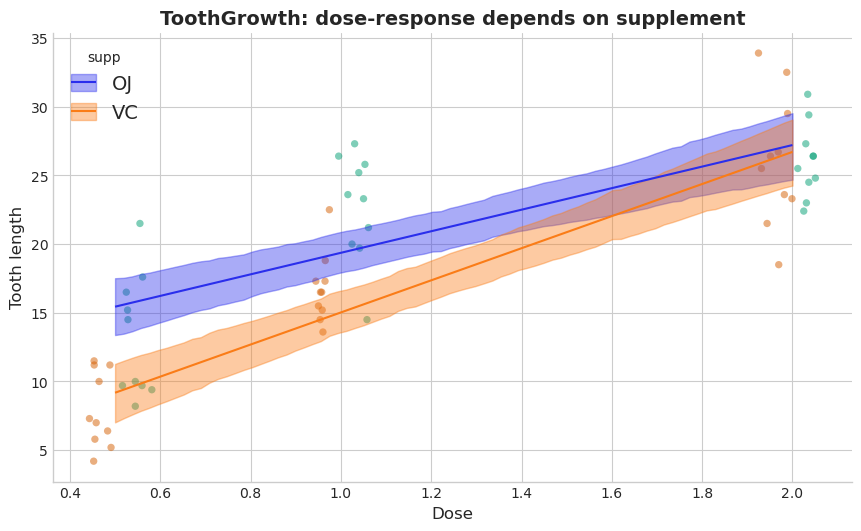

In [233]:
posterior_tooth = az.extract(idata_tooth_dose_supp)

supp_colors = {"VC": COLORS["contrast"], "OJ": COLORS["predictive"]}
supp_offsets = {"VC": -0.035, "OJ": 0.035}

fig, ax = plt.subplots(figsize=(8.5, 5.2))
tooth_pp_rng = np.random.default_rng(RANDOM_SEED + 9331)
for supp, color in supp_colors.items():
    supp_data = tooth.loc[tooth["supp"] == supp]
    jitter = tooth_pp_rng.normal(0, 0.018, size=len(supp_data))
    ax.scatter(
        supp_data["dose"] + supp_offsets[supp] + jitter,
        supp_data["len"],
        s=28,
        alpha=0.5,
        color=color,
        edgecolor="none",
        zorder=1,
    )

bmb.interpret.plot_predictions(
    tooth_dose_supp_model,
    idata_tooth_dose_supp,
    conditional={"dose": np.linspace(tooth["dose"].min(), tooth["dose"].max(), 80), "supp": ["VC", "OJ"]},
    ax=ax,
)
style_axis(ax, "ToothGrowth: dose-response depends on supplement", LABELS["dose"], LABELS["len"])
plt.show()


### 9.3.31 Posterior interaction uncertainty


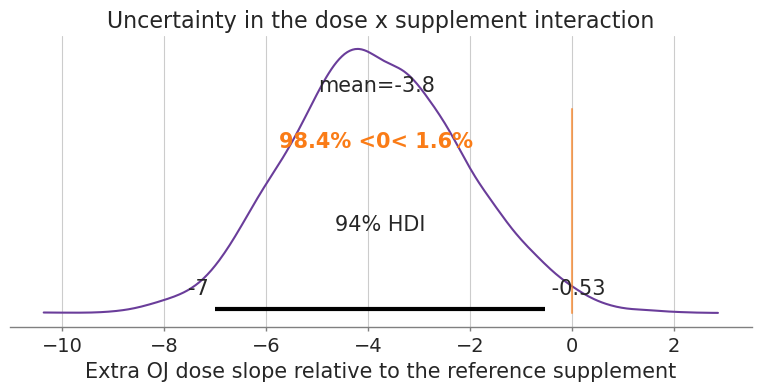

,mean,sd,hdi_3%,hdi_97%
dose,11.683,1.232,9.325,13.946
supp[OJ],8.182,2.320,3.841,12.365
dose:supp[OJ],-3.841,1.747,-6.996,-0.533
sigma,4.163,0.403,3.439,4.909


In [234]:
supp_contrast_level = str(posterior_tooth["dose:supp"]["dose:supp_dim"].values[0])
beta_dose_supp_draws = posterior_tooth["dose:supp"].isel({"dose:supp_dim": 0}).to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
az.plot_posterior(
    beta_dose_supp_draws,
    hdi_prob=0.94,
    ref_val=0,
    ax=ax,
    color=COLORS["interaction"],
)
ax.set_title("Uncertainty in the dose x supplement interaction")
ax.set_xlabel(f"Extra {supp_contrast_level} dose slope relative to the reference supplement")
plt.show()

tooth_summary = az.summary(idata_tooth_dose_supp, var_names=["dose", "supp", "dose:supp", "sigma"])
display(tooth_summary[["mean", "sd", "hdi_3%", "hdi_97%"]])


<a id="section-94"></a>
## 9.4 Continuous versus categorized predictors

The births14 data ask a modeling-choice question: should gestation enter the
model as a continuous week-by-week predictor, or should we collapse it into
clinically meaningful categories? Continuous predictors preserve graded
information; categories can be easier to interpret, but they also discard detail
and can create imbalanced cells.

### 9.4.36 Birth weight versus gestation


C:\Users\User\AppData\Local\Temp\ipykernel_27100\3369830712.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


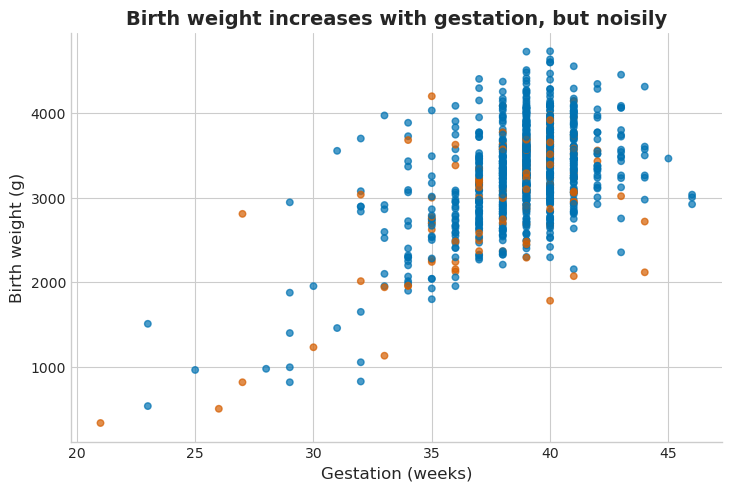

In [235]:
fig, ax = plt.subplots()
colors = births14["smoking"].map({"nonsmoker": COLORS["nonsmoker"], "smoker": COLORS["smoker"]})
ax.scatter(births14["gestation_weeks"], births14["birth_weight"], s=22, alpha=0.7, color=colors)
style_axis(ax, "Birth weight increases with gestation, but noisily", LABELS["gestation_weeks"], LABELS["birth_weight"])
ax.legend()
plt.show()


### 9.4.37 Prepare births14 variables for Bambi models


In [236]:
births_model_df = births14[[
    "birth_weight",
    "gestation_weeks",
    "smoking",
    "gestation_category",
]].dropna().copy()
birth_weight = births_model_df["birth_weight"].to_numpy()
births_model_df["smoker"] = (births_model_df["smoking"] == "smoker").astype(float)

### 9.4.38 Additive smoking shift: `birth_weight ~ gestation_weeks + smoking`


In [237]:
birth_gestation_smoking_model = bmb.Model(
    "birth_weight ~ gestation_weeks + smoking",
    data=births_model_df,
)


In [177]:
idata_birth_gestation_smoking = birth_gestation_smoking_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
birth_gestation_smoking_model.predict(idata_birth_gestation_smoking, kind="response", inplace=True, random_seed=RANDOM_SEED)

check_diagnostics(idata_birth_gestation_smoking, ["Intercept", "gestation_weeks", "smoking", "sigma"])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, gestation_weeks, smoking]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 82 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,-1452.914,237.598,-1891.673,-1013.963,6927.0,3559.0,1.0
gestation_weeks,122.558,6.107,111.409,134.027,7001.0,3638.0,1.0
smoking[smoker],-175.865,47.776,-261.325,-83.772,6101.0,3132.0,1.0
sigma,490.352,10.710,470.265,510.394,7727.0,2961.0,1.0


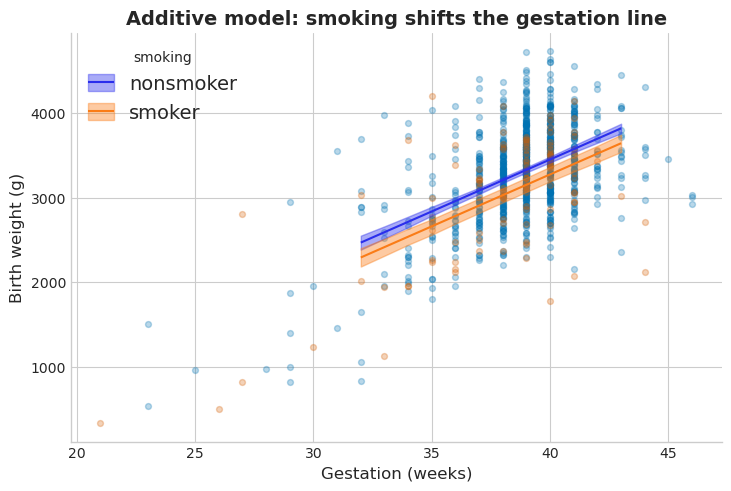

In [238]:
posterior_birth_add = az.extract(idata_birth_gestation_smoking)

fig, ax = plt.subplots()
for smoking_group in ["nonsmoker", "smoker"]:
    group_data = births_model_df.loc[births_model_df["smoking"] == smoking_group]
    ax.scatter(
        group_data["gestation_weeks"],
        group_data["birth_weight"],
        s=18,
        alpha=0.28,
        color=COLORS[smoking_group],
        label="_nolegend_",
        zorder=1,
    )

bmb.interpret.plot_predictions(
    birth_gestation_smoking_model,
    idata_birth_gestation_smoking,
    conditional={
        "gestation_weeks": np.linspace(
            births_model_df["gestation_weeks"].quantile(0.02),
            births_model_df["gestation_weeks"].quantile(0.98),
            80,
        ),
        "smoking": ["nonsmoker", "smoker"],
    },
    ax=ax,
)
style_axis(ax, "Additive model: smoking shifts the gestation line", LABELS["gestation_weeks"], LABELS["birth_weight"])
plt.show()


### 9.4.39 Interaction uncertainty: `birth_weight ~ gestation_weeks * smoking`


In [180]:
birth_gestation_smoking_interaction_model = bmb.Model(
    "birth_weight ~ gestation_weeks * smoking",
    data=births_model_df,
)


In [181]:
idata_birth_gestation_smoking_interaction = birth_gestation_smoking_interaction_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
birth_gestation_smoking_interaction_model.predict(
    idata_birth_gestation_smoking_interaction,
    kind="response",
    inplace=True,
    random_seed=RANDOM_SEED,
)

check_diagnostics(
    idata_birth_gestation_smoking_interaction,
    ["Intercept", "gestation_weeks", "smoking", "gestation_weeks:smoking", "sigma"],
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, gestation_weeks, smoking, gestation_weeks:smoking]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
Intercept,-1338.324,272.939,-1853.683,-820.826,2220.0,2468.0,1.0
gestation_weeks,119.598,7.027,106.297,132.862,2211.0,2454.0,1.0
smoking[smoker],-690.403,585.954,-1760.188,441.184,1658.0,1817.0,1.0
gestation_weeks:smoking[smoker],13.464,15.306,-16.700,41.071,1667.0,1795.0,1.0
sigma,490.688,11.322,469.995,512.822,2826.0,2733.0,1.0


C:\Users\User\AppData\Local\Temp\ipykernel_27100\512538894.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


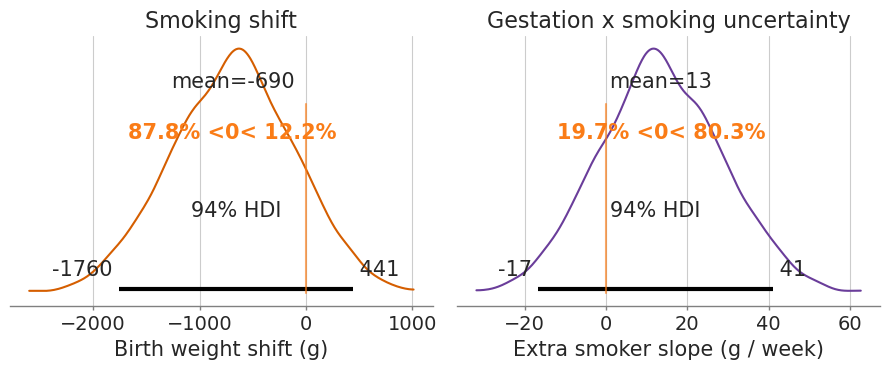

In [182]:
posterior_birth_int = az.extract(idata_birth_gestation_smoking_interaction)
smoking_shift_draws = posterior_birth_int["smoking"].sel(smoking_dim="smoker").to_numpy()
gestation_smoking_draws = posterior_birth_int["gestation_weeks:smoking"].sel({"gestation_weeks:smoking_dim": "smoker"}).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
az.plot_posterior(smoking_shift_draws, ref_val=0, ax=axes[0], color=COLORS["smoker"])
axes[0].set_title("Smoking shift")
axes[0].set_xlabel("Birth weight shift (g)")
az.plot_posterior(gestation_smoking_draws, ref_val=0, ax=axes[1], color=COLORS["interaction"])
axes[1].set_title("Gestation x smoking uncertainty")
axes[1].set_xlabel("Extra smoker slope (g / week)")
plt.tight_layout()
plt.show()


In [ ]:
idata

array([[<Axes: ylabel='gestation_weeks'>, <Axes: >],
       [<Axes: xlabel='smoking\nsmoker', ylabel='gestation_weeks:smoking\nsmoker'>,
        <Axes: xlabel='gestation_weeks'>]], dtype=object)

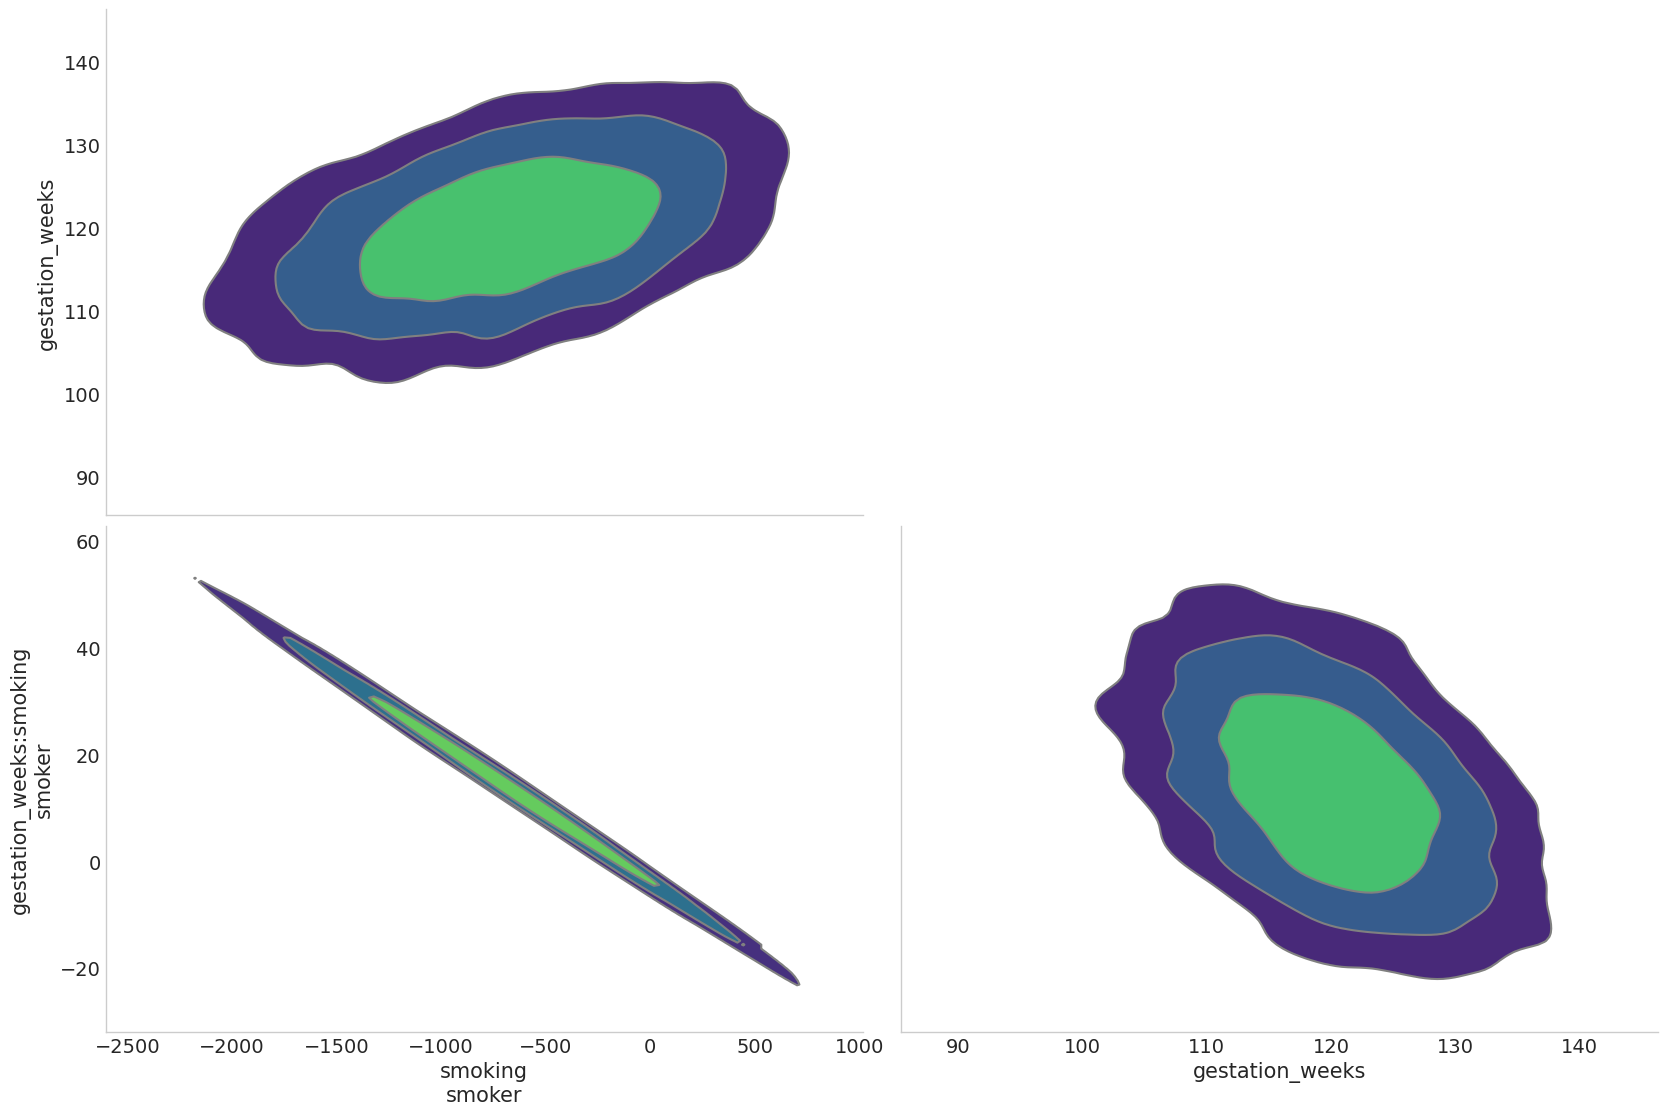

In [184]:
az.plot_pair(idata_birth_gestation_smoking_interaction.posterior, 
             var_names=["smoking", "gestation_weeks", "gestation_weeks:smoking"], kind="kde")

### 9.4.40 Gestation-category interaction and cell count imbalance

Here we turn continuous gestational age into three explicit groups:

| Category | Weeks |
| --- | --- |
| Very preterm | <32 |
| Preterm | 32 to <37 |
| Early/full term | >=37 |

Model statement: `birth_weight ~ gestation_category * smoking`.

In [239]:
births_model_df["gestation_category_smoking"] = [
    f"{gestation_category}, {smoking}"
    for gestation_category, smoking in zip(
        births_model_df["gestation_category"],
        births_model_df["smoking"],
    )
]
birth_cell_labels = [
    f"{gestation_category}, {smoking}"
    for gestation_category in gestation_category_order
    for smoking in ["nonsmoker", "smoker"]
]

birth_gestation_category_smoking_model = bmb.Model(
    "birth_weight ~ 0 + gestation_category:smoking",
    data=births_model_df,
)
birth_gestation_category_smoking_model.build()

In [240]:
idata_birth_gestation_category_smoking = birth_gestation_category_smoking_model.fit(
    random_seed=RANDOM_SEED,
    include_response_params=True,
)
birth_gestation_category_smoking_model.predict(
    idata_birth_gestation_category_smoking,
    kind="response",
    inplace=True,
    random_seed=RANDOM_SEED,
)

check_diagnostics(idata_birth_gestation_category_smoking, ["gestation_category:smoking", "sigma"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, gestation_category:smoking]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 127 seconds.


**Divergences:** 0

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
"gestation_category:smoking[very preterm, nonsmoker]",1581.746,140.063,1330.354,1855.365,6651.0,3543.0,1.0
"gestation_category:smoking[very preterm, smoker]",1146.356,226.584,697.104,1557.645,5245.0,3184.0,1.0
"gestation_category:smoking[preterm, nonsmoker]",2720.087,53.152,2623.723,2821.910,5369.0,3012.0,1.0
"gestation_category:smoking[preterm, smoker]",2575.280,111.010,2370.846,2784.057,4567.0,2847.0,1.0
"gestation_category:smoking[early/full term, nonsmoker]",3386.865,18.222,3351.736,3419.125,5042.0,2926.0,1.0
"gestation_category:smoking[early/full term, smoker]",3235.593,53.357,3133.073,3333.034,5205.0,2658.0,1.0
sigma,491.425,10.937,470.947,512.102,5197.0,3281.0,1.0


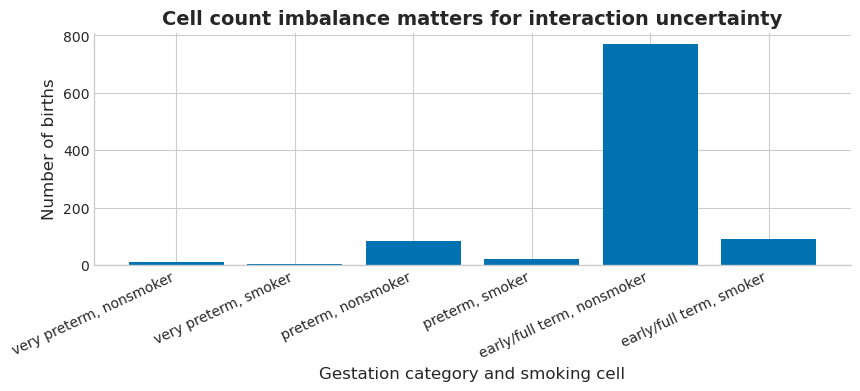

In [241]:
cell_counts = births_model_df["gestation_category_smoking"].value_counts().reindex(birth_cell_labels)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.bar(cell_counts.index, cell_counts.values, color=COLORS["mean"])
ax.set_xticks(np.arange(len(cell_counts)))
ax.set_xticklabels(cell_counts.index, rotation=25, ha="right")
style_axis(ax, "Cell count imbalance matters for interaction uncertainty", "Gestation category and smoking cell", "Number of births")
plt.show()

### 9.4.41 Posterior cell means


In [ ]:
posterior_birth_cell = idata_birth_gestation_category_smoking.posterior["gestation_category:smoking"].rename(
    {"gestation_category:smoking_dim": "cell"}
)
birth_cell_mean = posterior_birth_cell.mean(("chain", "draw")).to_pandas().reindex(birth_cell_labels)
birth_cell_hdi = (
    az.hdi(posterior_birth_cell, hdi_prob=0.94)
    .to_array()
    .squeeze()
    .transpose("cell", "hdi")
    .to_pandas()
    .reindex(birth_cell_labels)
)

birth_cell_summary = az.summary(
    posterior_birth_cell.to_dataset(name="cell_mean_birth_weight"),
    var_names=["cell_mean_birth_weight"],
)
birth_cell_summary_display = birth_cell_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].copy()
birth_cell_summary_display.index = birth_cell_labels
display(birth_cell_summary_display)

birth_cell_plot_labels = [
    label.replace("early/full term", "early/full").replace(", ", "\n")
    for label in birth_cell_labels
]
birth_cell_colors = [
    COLORS["nonsmoker"] if label.endswith("nonsmoker") else COLORS["smoker"]
    for label in birth_cell_labels
]
y_positions = np.arange(len(birth_cell_labels))
x_error = np.vstack(
    [
        birth_cell_mean.to_numpy() - birth_cell_hdi["lower"].to_numpy(),
        birth_cell_hdi["higher"].to_numpy() - birth_cell_mean.to_numpy(),
    ]
)

fig, ax = plt.subplots(figsize=(7.2, 4.1))
for y_position, mean_value, error_values, color in zip(
    y_positions,
    birth_cell_mean.to_numpy(),
    x_error.T,
    birth_cell_colors,
):
    ax.errorbar(
        mean_value,
        y_position,
        xerr=error_values.reshape(2, 1),
        fmt="o",
        color=color,
        ecolor=color,
        capsize=4,
        elinewidth=2.2,
        markersize=6,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(birth_cell_plot_labels, fontsize=9)
ax.invert_yaxis()
style_axis(ax, "Posterior cell means", LABELS["birth_weight"], "")
plt.tight_layout()
plt.show()

### 9.4.42 Continuous versus categorized gestation comparison


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.9), sharey=True)
axes[0].scatter(births_model_df["gestation_weeks"], birth_weight, s=18, alpha=0.35, color=COLORS["observed"])
axes[0].set_title("Continuous gestation")
axes[0].set_xlabel(LABELS["gestation_weeks"])
axes[0].set_ylabel(LABELS["birth_weight"])

birth_box_data = [
    births_model_df.loc[births_model_df["gestation_category"] == group, "birth_weight"]
    for group in gestation_category_order
]
axes[1].boxplot(
    birth_box_data,
    labels=["very\npreterm", "preterm", "early/full\nterm"],
    patch_artist=True,
)
axes[1].set_title("Categorized gestation")
axes[1].set_xlabel("Gestation category")
plt.tight_layout()
plt.show()

<a id="section-95"></a>
## 9.5 Whole-model effect sizes

Effect sizes ask about magnitude. Here we use the same categorical interaction
model from the previous section, `birth_weight ~ 0 + gestation_category:smoking`,
so the variance explanations are tied to the six birth-weight cells students have
just seen.

### 9.5.45 R-squared for the categorical interaction model

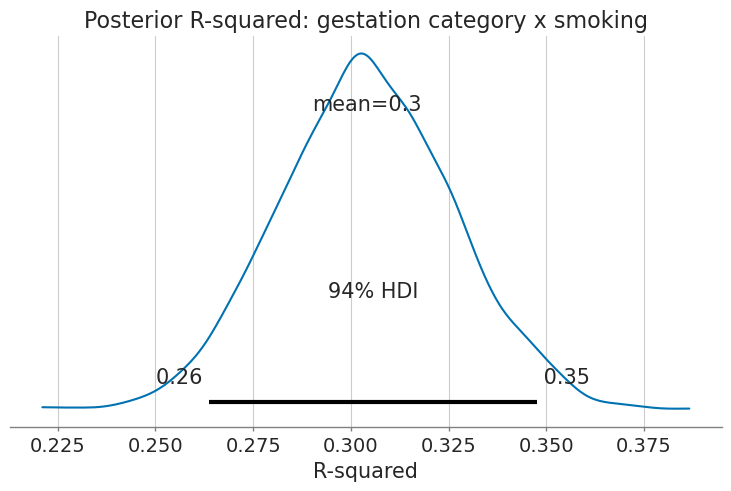

In [9]:
posterior_birth_category = idata_birth_gestation_category_smoking.posterior
posterior_birth_cell = posterior_birth_category["gestation_category:smoking"].rename(
    {"gestation_category:smoking_dim": "cell"}
).sel(cell=birth_cell_labels)

birth_cell_info = pd.DataFrame(
    {
        "cell": birth_cell_labels,
        "gestation_category": [label.split(", ")[0] for label in birth_cell_labels],
        "smoking": [label.split(", ")[1] for label in birth_cell_labels],
        "n": births_model_df["gestation_category_smoking"].value_counts().reindex(birth_cell_labels).to_numpy(),
    }
)
birth_cell_n = birth_cell_info["n"].to_numpy()
n_births = birth_cell_n.sum()

birth_cell_draws = posterior_birth_cell.stack(sample=("chain", "draw")).transpose("sample", "cell").to_numpy()
sigma_birth_draws = az.extract(idata_birth_gestation_category_smoking, group="posterior")["sigma"].to_numpy()

birth_cell_grand_mean = (birth_cell_draws * birth_cell_n).sum(axis=1) / n_births
birth_cell_variance = (
    birth_cell_n
    * (birth_cell_draws - birth_cell_grand_mean[:, None]) ** 2
).sum(axis=1) / n_births

r2_birth_category_interaction = birth_cell_variance / (
    birth_cell_variance + sigma_birth_draws**2
)

fig, ax = plt.subplots()
az.plot_posterior(
    r2_birth_category_interaction,
    hdi_prob=0.94,
    ax=ax,
    color=COLORS["mean"],
)
ax.set_title("Posterior R-squared: gestation category x smoking")
ax.set_xlabel("R-squared")
plt.show()

### 9.5.46 Partial R-squared: what do the model terms add?

We do not fit reduced models here. Instead, we decompose the posterior cell means
from `birth_weight ~ 0 + gestation_category:smoking` into gestation-category,
smoking, and interaction components. For each component, partial R-squared is the
component variance divided by component variance plus posterior residual
variance.

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


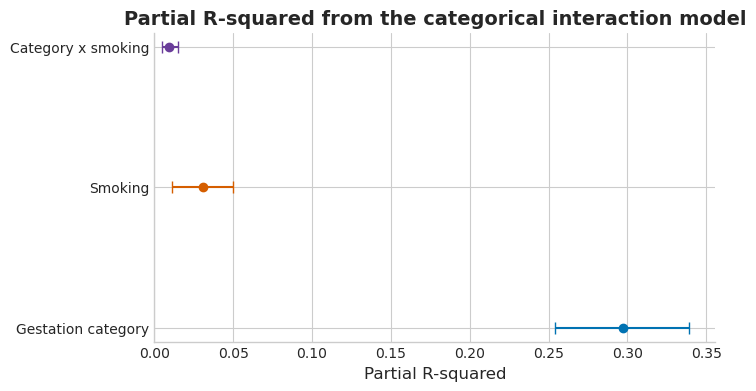

,mean,hdi_3%,hdi_97%
Gestation category,0.297,0.254,0.339
Smoking,0.031,0.011,0.050
Category x smoking,0.009,0.005,0.015


In [10]:
category_indicator = pd.get_dummies(
    birth_cell_info["gestation_category"],
).reindex(columns=gestation_category_order).to_numpy()
smoking_indicator = pd.get_dummies(
    birth_cell_info["smoking"],
).reindex(columns=["nonsmoker", "smoker"]).to_numpy()

n_by_category = birth_cell_n @ category_indicator
n_by_smoking = birth_cell_n @ smoking_indicator

category_mean_draws = (birth_cell_draws * birth_cell_n) @ category_indicator / n_by_category
smoking_mean_draws = (birth_cell_draws * birth_cell_n) @ smoking_indicator / n_by_smoking

category_component_draws = (
    category_mean_draws - birth_cell_grand_mean[:, None]
) @ category_indicator.T
smoking_component_draws = (
    smoking_mean_draws - birth_cell_grand_mean[:, None]
) @ smoking_indicator.T
additive_cell_draws = (
    birth_cell_grand_mean[:, None]
    + category_component_draws
    + smoking_component_draws
)
interaction_component_draws = birth_cell_draws - additive_cell_draws

category_variance = (
    birth_cell_n
    * category_component_draws**2
).sum(axis=1) / n_births
smoking_variance = (
    birth_cell_n
    * smoking_component_draws**2
).sum(axis=1) / n_births
interaction_variance = (
    birth_cell_n
    * interaction_component_draws**2
).sum(axis=1) / n_births

partial_r2_gestation_category = category_variance / (
    category_variance + sigma_birth_draws**2
)
partial_r2_smoking = smoking_variance / (
    smoking_variance + sigma_birth_draws**2
)
partial_r2_category_interaction = interaction_variance / (
    interaction_variance + sigma_birth_draws**2
)

partial_r2_terms = pd.DataFrame(
    {
        "Gestation category": partial_r2_gestation_category,
        "Smoking": partial_r2_smoking,
        "Category x smoking": partial_r2_category_interaction,
    }
)
partial_r2_summary = az.summary(
    partial_r2_terms.to_dict(orient="list"),
    hdi_prob=0.94,
)[["mean", "hdi_3%", "hdi_97%"]]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
y_positions = np.arange(len(partial_r2_summary))
term_colors = [COLORS["mean"], COLORS["smoker"], COLORS["interaction"]]

for y_position, term_name, color in zip(y_positions, partial_r2_summary.index, term_colors):
    row = partial_r2_summary.loc[term_name]
    ax.errorbar(
        row["mean"],
        y_position,
        xerr=[
            [row["mean"] - row["hdi_3%"]],
            [row["hdi_97%"] - row["mean"]],
        ],
        fmt="o",
        capsize=4,
        color=color,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(partial_r2_summary.index)
ax.set_xlim(left=0)
style_axis(
    ax,
    "Partial R-squared from the categorical interaction model",
    "Partial R-squared",
    "",
)
plt.show()

partial_r2_summary

### 9.5.47 Eta-squared for the model terms

Eta-squared compares a term's variance contribution with the full modeled
variance. Here we use the same posterior components from the fitted cell model,
so the display is parallel to the partial R-squared figure above.

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


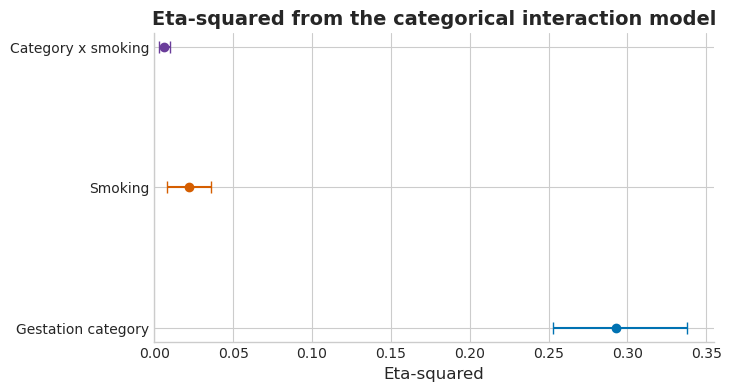

,mean,hdi_3%,hdi_97%
Gestation category,0.293,0.253,0.338
Smoking,0.022,0.008,0.036
Category x smoking,0.006,0.003,0.010


In [11]:
eta2_denominator = birth_cell_variance + sigma_birth_draws**2

eta2_gestation_category = category_variance / eta2_denominator
eta2_smoking = smoking_variance / eta2_denominator
eta2_category_interaction = interaction_variance / eta2_denominator

eta2_terms = pd.DataFrame(
    {
        "Gestation category": eta2_gestation_category,
        "Smoking": eta2_smoking,
        "Category x smoking": eta2_category_interaction,
    }
)
eta2_summary = az.summary(
    eta2_terms.to_dict(orient="list"),
    hdi_prob=0.94,
)[["mean", "hdi_3%", "hdi_97%"]]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
y_positions = np.arange(len(eta2_summary))
term_colors = [COLORS["mean"], COLORS["smoker"], COLORS["interaction"]]

for y_position, term_name, color in zip(y_positions, eta2_summary.index, term_colors):
    row = eta2_summary.loc[term_name]
    ax.errorbar(
        row["mean"],
        y_position,
        xerr=[
            [row["mean"] - row["hdi_3%"]],
            [row["hdi_97%"] - row["mean"]],
        ],
        fmt="o",
        capsize=4,
        color=color,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(eta2_summary.index)
ax.set_xlim(left=0)
style_axis(
    ax,
    "Eta-squared from the categorical interaction model",
    "Eta-squared",
    "",
)
plt.show()

eta2_summary

### 9.5.48 Cohen's f for the model terms

Cohen's f is a rescaling of eta-squared: larger eta-squared values become larger
standardized effect sizes. We keep the same three model-term rows so the
effect-size displays can be read together.

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


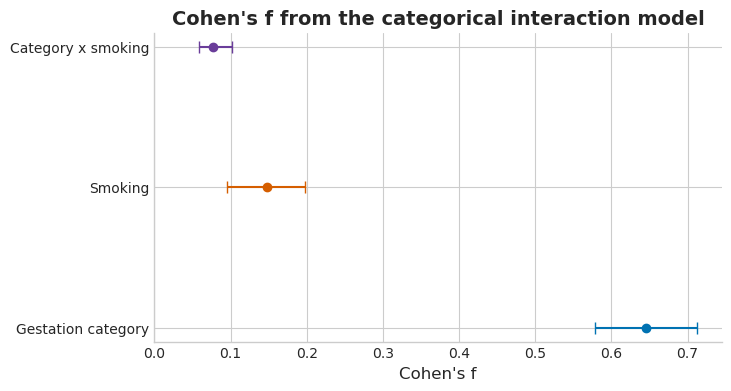

,mean,hdi_3%,hdi_97%
Gestation category,0.645,0.579,0.712
Smoking,0.148,0.096,0.198
Category x smoking,0.077,0.059,0.102


In [12]:
cohen_f_gestation_category = np.sqrt(
    eta2_gestation_category / (1 - eta2_gestation_category)
)
cohen_f_smoking = np.sqrt(
    eta2_smoking / (1 - eta2_smoking)
)
cohen_f_category_interaction = np.sqrt(
    eta2_category_interaction / (1 - eta2_category_interaction)
)

cohen_f_terms = pd.DataFrame(
    {
        "Gestation category": cohen_f_gestation_category,
        "Smoking": cohen_f_smoking,
        "Category x smoking": cohen_f_category_interaction,
    }
)
cohen_f_summary = az.summary(
    cohen_f_terms.to_dict(orient="list"),
    hdi_prob=0.94,
)[["mean", "hdi_3%", "hdi_97%"]]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
y_positions = np.arange(len(cohen_f_summary))
term_colors = [COLORS["mean"], COLORS["smoker"], COLORS["interaction"]]

for y_position, term_name, color in zip(y_positions, cohen_f_summary.index, term_colors):
    row = cohen_f_summary.loc[term_name]
    ax.errorbar(
        row["mean"],
        y_position,
        xerr=[
            [row["mean"] - row["hdi_3%"]],
            [row["hdi_97%"] - row["mean"]],
        ],
        fmt="o",
        capsize=4,
        color=color,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(cohen_f_summary.index)
ax.set_xlim(left=0)
style_axis(
    ax,
    "Cohen's f from the categorical interaction model",
    "Cohen's f",
    "",
)
plt.show()

cohen_f_summary

<a id="section-96"></a>
## 9.6 Interaction interpretation

An interaction is not only a coefficient. Scientific interpretation usually asks:
what is the expected outcome under meaningful combinations of predictors?


### 9.6.50 Conditional effects for ToothGrowth


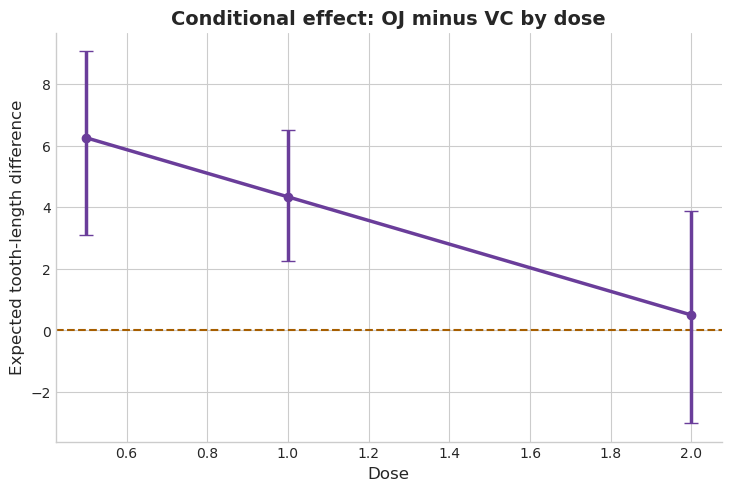

In [147]:
selected_doses = np.array([0.5, 1.0, 2.0])
supp_contrast_level = str(posterior_tooth["supp"]["supp_dim"].values[0])
supplement_contrast = (
    posterior_tooth["supp"].isel(supp_dim=0).to_numpy()[:, None]
    + posterior_tooth["dose:supp"].isel({"dose:supp_dim": 0}).to_numpy()[:, None] * selected_doses[None, :]
)

if supp_contrast_level == "OJ":
    oj_minus_vc = supplement_contrast
else:
    oj_minus_vc = -supplement_contrast

diff_mean = oj_minus_vc.mean(axis=0)
diff_hdi = az.hdi(oj_minus_vc, hdi_prob=0.94)

fig, ax = plt.subplots()
ax.axhline(0, color=COLORS["reference"], ls="--")
ax.errorbar(selected_doses, diff_mean,
            yerr=[diff_mean - diff_hdi[:, 0], diff_hdi[:, 1] - diff_mean],
            fmt="o-", color=COLORS["interaction"], capsize=5, lw=2.5)
style_axis(ax, "Conditional effect: OJ minus VC by dose", LABELS["dose"], "Expected tooth-length difference")
plt.show()


### 9.6.51 Weak versus strong interaction comparison


C:\Users\User\AppData\Local\Temp\ipykernel_27100\3327468393.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


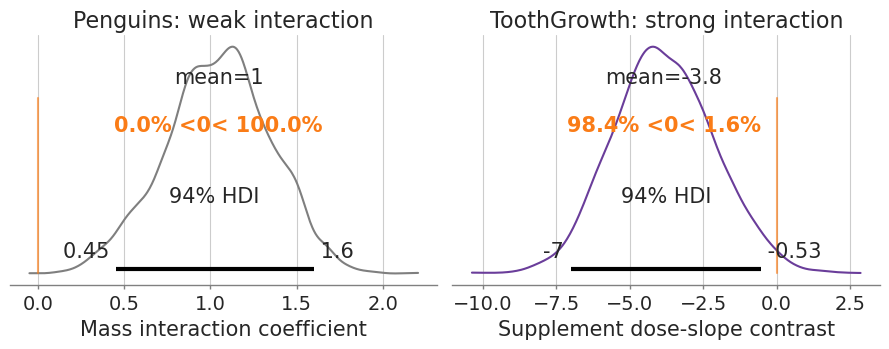

In [148]:
weak_interaction = az.extract(idata_mass_flipper_bill)["flipper_length_mm:bill_length_mm"].to_numpy()
strong_interaction = posterior_tooth["dose:supp"].isel({"dose:supp_dim": 0}).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
az.plot_posterior(weak_interaction, ref_val=0, ax=axes[0], color=COLORS["residual"])
axes[0].set_title("Penguins: weak interaction")
axes[0].set_xlabel("Mass interaction coefficient")
az.plot_posterior(strong_interaction, ref_val=0, ax=axes[1], color=COLORS["interaction"])
axes[1].set_title("ToothGrowth: strong interaction")
axes[1].set_xlabel("Supplement dose-slope contrast")
plt.tight_layout()
plt.show()


### 9.6.52 Scientific reading of interaction contrasts


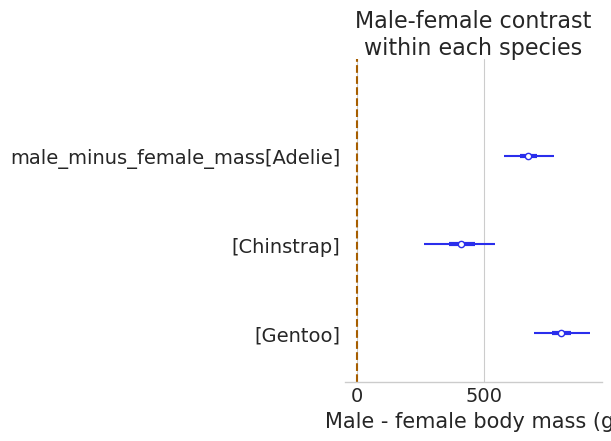

In [149]:
sex_contrast_by_species = xr.concat(
    [male_female_by_species[species] for species in species_order],
    dim=pd.Index(species_order, name="species"),
)

ax = az.plot_forest(
    sex_contrast_by_species.to_dataset(name="male_minus_female_mass"),
    var_names=["male_minus_female_mass"],
    combined=True,
    hdi_prob=0.94,
)[0]
ax.axvline(0, color=COLORS["reference"], ls="--")
ax.set_title("Male-female contrast within each species")
ax.set_xlabel("Male - female body mass (g)")
plt.show()


<a id="section-97"></a>
## 9.7 Modeling choices with messy data

We do not use formal model comparison yet. The point is to see the tradeoff:
interactions can express important scientific ideas, but they spend information
on more parameters and can widen uncertainty.


### 9.7.60 Multiple plausible model structures


In [ ]:
model_choice_table = pd.DataFrame(
    {
        "Model": [
            "gestation + smoking",
            "gestation * smoking",
            "gestation category * smoking",
        ],
        "Question": [
            "Is there an average smoking shift after gestation?",
            "Does the smoking shift change across gestational age?",
            "Do smoking contrasts differ across gestation categories?",
        ],
        "Cost": [
            "Few parameters; assumes parallel lines.",
            "Adds a slope interaction; harder to estimate.",
            "Simple cells; loses continuous gestation information.",
        ],
    }
)
display(model_choice_table)

### 9.7.61 Weak effects and wide uncertainty


C:\Users\User\AppData\Local\Temp\ipykernel_27100\3476133323.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


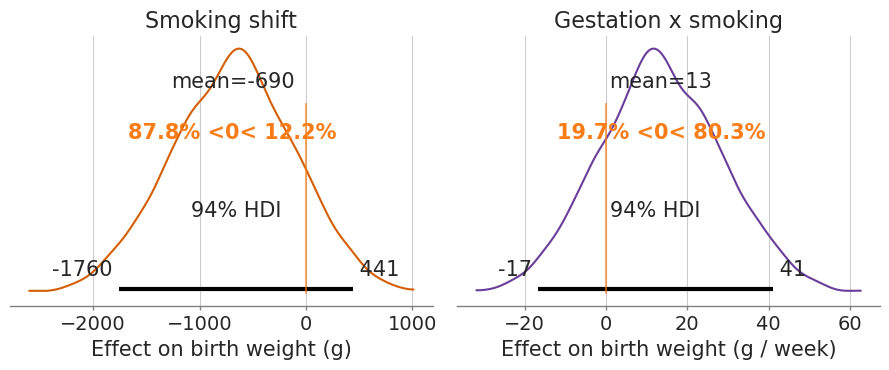

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
az.plot_posterior(smoking_shift_draws, ref_val=0, ax=axes[0], color=COLORS["smoker"])
axes[0].set_title("Smoking shift")
axes[0].set_xlabel("Effect on birth weight (g)")
az.plot_posterior(gestation_smoking_draws, ref_val=0, ax=axes[1], color=COLORS["interaction"])
axes[1].set_title("Gestation x smoking")
axes[1].set_xlabel("Effect on birth weight (g / week)")
plt.tight_layout()
plt.show()


### 9.7.62 Interaction cost example


C:\Users\User\AppData\Local\Temp\ipykernel_27100\547302422.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(interval_widths.index, rotation=20, ha="right")


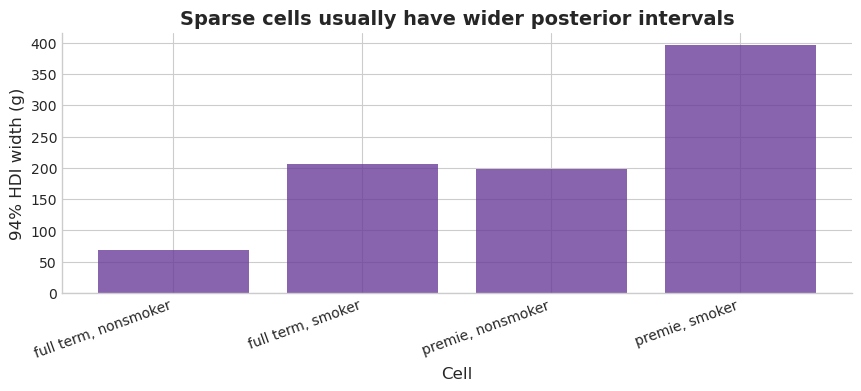

In [165]:
interval_widths = (birth_cell_hdi["higher"] - birth_cell_hdi["lower"]).reindex(birth_cell_labels)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.bar(interval_widths.index, interval_widths.values, color=COLORS["interaction"], alpha=0.8)
ax.set_xticklabels(interval_widths.index, rotation=20, ha="right")
style_axis(ax, "Sparse cells usually have wider posterior intervals", "Cell", "94% HDI width (g)")
plt.show()


<a id="section-98"></a>
## 9.8 Frequentist translation

This section translates model questions into the frequentist ANOVA language.
It is conceptual: formal post-hoc testing and model comparison wait for Lecture 10.


### 9.8.66 Omnibus F explanation


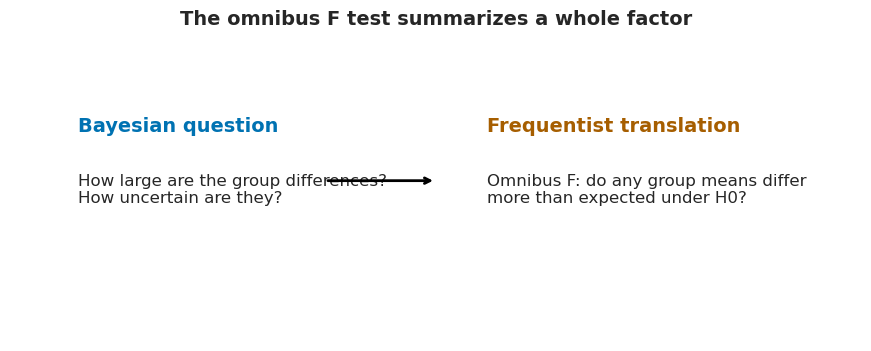

In [166]:
fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.axis("off")
ax.text(0.08, 0.68, "Bayesian question", fontsize=14, weight="bold", color=COLORS["mean"])
ax.text(0.08, 0.45, "How large are the group differences?\nHow uncertain are they?", fontsize=12)
ax.annotate("", xy=(0.50, 0.52), xytext=(0.37, 0.52), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.56, 0.68, "Frequentist translation", fontsize=14, weight="bold", color=COLORS["reference"])
ax.text(0.56, 0.45, "Omnibus F: do any group means differ\nmore than expected under H0?", fontsize=12)
ax.set_title("The omnibus F test summarizes a whole factor", fontsize=14, weight="bold")
plt.show()


### 9.8.67 Nested-model diagrams and partial F


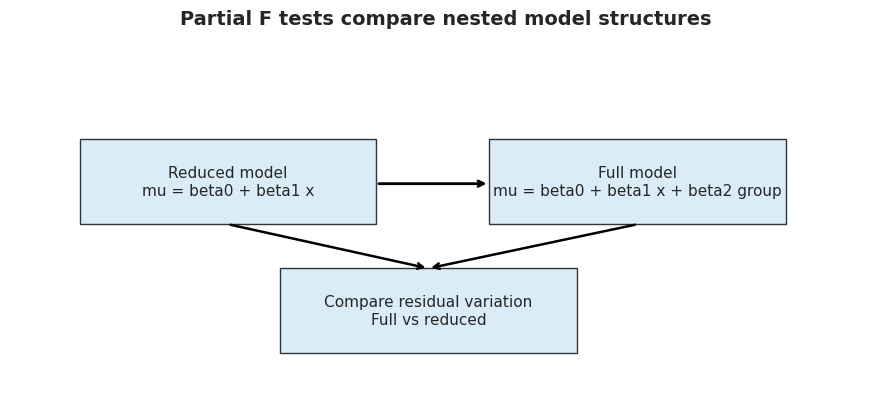

In [167]:
fig, ax = plt.subplots(figsize=(8.8, 4.0))
ax.axis("off")
boxes = [
    ("Reduced model\nmu = beta0 + beta1 x", (0.08, 0.48)),
    ("Full model\nmu = beta0 + beta1 x + beta2 group", (0.55, 0.48)),
    ("Compare residual variation\nFull vs reduced", (0.31, 0.13)),
]
for text, (xpos, ypos) in boxes:
    rect = plt.Rectangle((xpos, ypos), 0.34, 0.23, fill=True, color=COLORS["light"], ec=COLORS["observed"])
    ax.add_patch(rect)
    ax.text(xpos + 0.17, ypos + 0.115, text, ha="center", va="center", fontsize=11)
ax.annotate("", xy=(0.55, 0.59), xytext=(0.42, 0.59), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.48, 0.36), xytext=(0.25, 0.48), arrowprops=dict(arrowstyle="->", lw=1.8))
ax.annotate("", xy=(0.48, 0.36), xytext=(0.72, 0.48), arrowprops=dict(arrowstyle="->", lw=1.8))
ax.set_title("Partial F tests compare nested model structures", fontsize=14, weight="bold")
plt.show()


### 9.8.68 ANOVA-table and interaction-testing schematic


In [168]:
anova_table = pd.DataFrame(
    {
        "Source": ["species", "sex", "species:sex", "Residual"],
        "What it asks": [
            "Do species means differ?",
            "Is there an average sex difference?",
            "Does the sex difference change by species?",
            "What variation is left unexplained?",
        ],
        "Bayesian analogue": [
            "Posterior group contrasts",
            "Posterior sex contrast",
            "Posterior interaction contrasts",
            "Posterior sigma and predictive checks",
        ],
    }
)
display(anova_table)


,Source,What it asks,Bayesian analogue
0,species,Do species means differ?,Posterior group contrasts
1,sex,Is there an average sex difference?,Posterior sex contrast
2,species:sex,Does the sex difference change by species?,Posterior interaction contrasts
3,Residual,What variation is left unexplained?,Posterior sigma and predictive checks


<a id="section-99"></a>
## 9.9 Assumptions and limitations

ANOVA and regression assumptions are assumptions about the data-generating model.
In Bayesian workflow we can check them with posterior predictive checks and, when
needed, change the model. One useful extension is to model `sigma` directly.


### 9.9.72 Homoscedasticity figure


C:\Users\User\AppData\Local\Temp\ipykernel_27100\1057380467.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


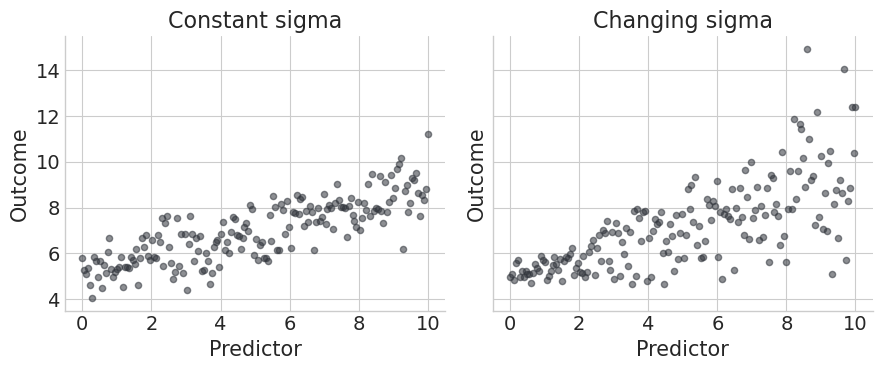

In [169]:
x_demo = np.linspace(0, 10, 180)
y_equal = 5 + 0.4 * x_demo + rng.normal(0, 0.8, size=len(x_demo))
y_fan = 5 + 0.4 * x_demo + rng.normal(0, 0.25 + 0.18 * x_demo, size=len(x_demo))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
axes[0].scatter(x_demo, y_equal, s=20, alpha=0.55, color=COLORS["observed"])
axes[0].set_title("Constant sigma")
axes[1].scatter(x_demo, y_fan, s=20, alpha=0.55, color=COLORS["observed"])
axes[1].set_title("Changing sigma")
for ax in axes:
    ax.set_xlabel("Predictor")
    ax.set_ylabel("Outcome")
plt.tight_layout()
plt.show()


### 9.9.73 Leverage and influence example


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, predictor]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, predictor]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.
Default computed for conditional variable: predictor
Default computed for conditional variable: predictor


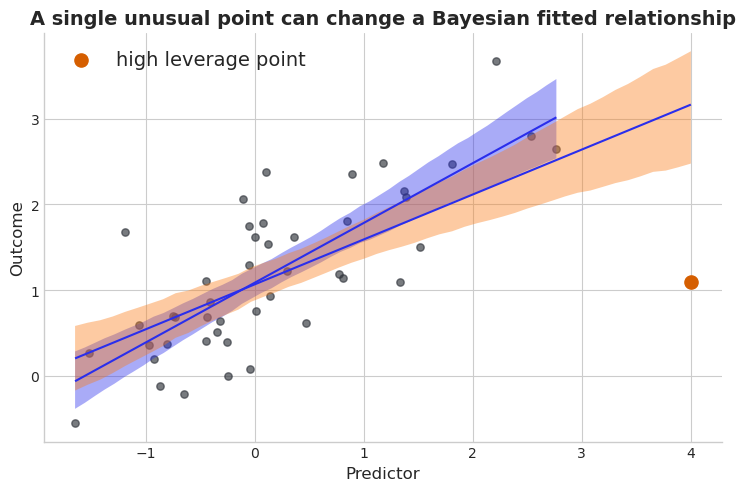

In [170]:
x_base = rng.normal(0, 1, size=45)
y_base = 1 + 0.7 * x_base + rng.normal(0, 0.55, size=45)
leverage_base = pd.DataFrame({"predictor": x_base, "outcome": y_base})
leverage_with_point = pd.concat(
    [
        leverage_base,
        pd.DataFrame({"predictor": [4.0], "outcome": [1.1]}),
    ],
    ignore_index=True,
)

leverage_model_base = bmb.Model("outcome ~ predictor", data=leverage_base)
leverage_model_with_point = bmb.Model("outcome ~ predictor", data=leverage_with_point)
idata_leverage_base = leverage_model_base.fit(random_seed=RANDOM_SEED, include_response_params=True)
idata_leverage_with_point = leverage_model_with_point.fit(random_seed=RANDOM_SEED, include_response_params=True)

fig, ax = plt.subplots()
ax.scatter(x_base, y_base, s=28, alpha=0.65, color=COLORS["observed"])
ax.scatter([4.0], [1.1], s=90, color=COLORS["contrast"], label="high leverage point")
bmb.interpret.plot_predictions(leverage_model_base, idata_leverage_base, conditional="predictor", ax=ax)
bmb.interpret.plot_predictions(leverage_model_with_point, idata_leverage_with_point, conditional="predictor", ax=ax)
style_axis(ax, "A single unusual point can change a Bayesian fitted relationship", "Predictor", "Outcome")
ax.legend(frameon=False)
plt.show()


### 9.9.74 Residual assumption figure


C:\Users\User\AppData\Local\Temp\ipykernel_27100\3158374346.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


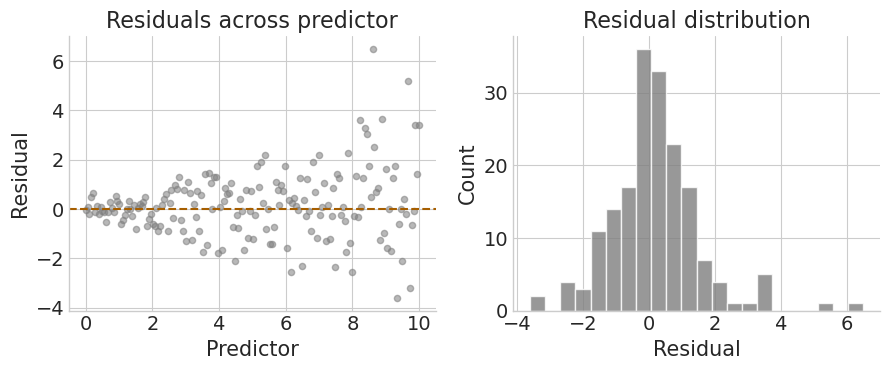

In [171]:
residuals = y_fan - (5 + 0.4 * x_demo)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].scatter(x_demo, residuals, s=20, alpha=0.55, color=COLORS["residual"])
axes[0].axhline(0, color=COLORS["reference"], ls="--")
axes[0].set_title("Residuals across predictor")
axes[0].set_xlabel("Predictor")
axes[0].set_ylabel("Residual")
axes[1].hist(residuals, bins=22, color=COLORS["residual"], alpha=0.8, edgecolor="white")
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


### 9.9.75 Variance-modeling schematic


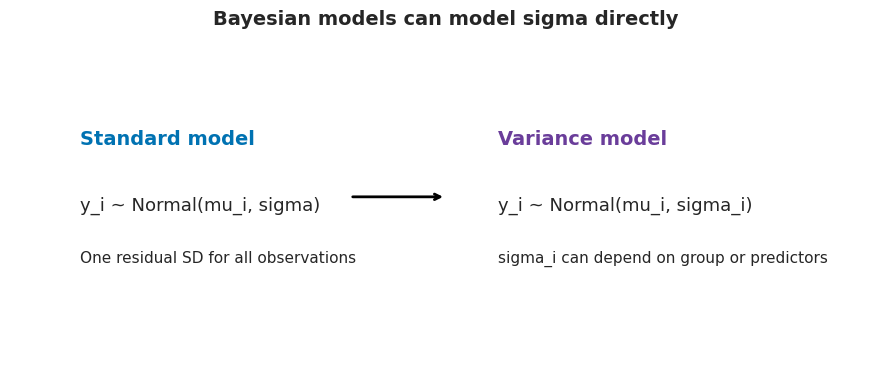

In [172]:
fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.axis("off")
ax.text(0.08, 0.66, "Standard model", fontsize=14, weight="bold", color=COLORS["mean"])
ax.text(0.08, 0.46, "y_i ~ Normal(mu_i, sigma)", fontsize=13)
ax.text(0.08, 0.30, "One residual SD for all observations", fontsize=11)
ax.annotate("", xy=(0.50, 0.50), xytext=(0.39, 0.50), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.56, 0.66, "Variance model", fontsize=14, weight="bold", color=COLORS["interaction"])
ax.text(0.56, 0.46, "y_i ~ Normal(mu_i, sigma_i)", fontsize=13)
ax.text(0.56, 0.30, "sigma_i can depend on group or predictors", fontsize=11)
ax.set_title("Bayesian models can model sigma directly", fontsize=14, weight="bold")
plt.show()


<a id="section-910"></a>
## 9.10 For next time

Next time we make model choices more formal: model comparison, post-hoc testing,
multiple comparisons, and information criteria such as AIC and BIC.
